In [1]:
import numpy as np
import sys
print(sys.executable)
import rebound
import astropy.constants as const
import astropy.units as u
import matplotlib.pyplot as plt
from plotting_params import use_my_style
import glob
import netCDF4
from netCDF4 import Dataset
import re
import os
from tqdm import tqdm
from matplotlib.lines import Line2D
from concurrent.futures import ProcessPoolExecutor
use_my_style()

/data/ally/my_env/bin/python


## 1) Calculate saturated water vapor pressure

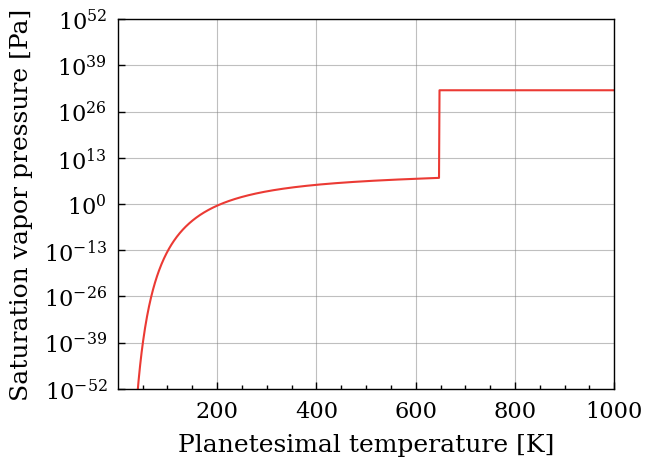

1.3070240132842796 Pa


In [6]:
def P_sat_vap(T_pl):

    Pc =22.065e6 * u.Pa
    Tc = 647.096 #Kelvin

    T_pl = np.asarray(T_pl, dtype=float)
    P_sat = np.full_like(T_pl, 1e32, dtype=float)
    mask = T_pl < Tc
    T_pl_valid = T_pl[mask]

    theta = T_pl_valid / Tc
    tau = 1 - theta
    a1, a2, a3, a4, a5, a6 = -7.85951783, 1.84408259, -11.7866497, 22.6807411, -15.9618719, 1.80122502
    log_p_over_pc = Tc/T_pl_valid * (a1*tau + a2*tau**1.5 + a3*tau**3 + a4*tau**3.5 + a5*tau**4 + a6*tau**7.5)

    P_sat[mask] = np.exp(log_p_over_pc) * Pc
    
    return P_sat*u.Pa

Ts = np.linspace(1, 1000, 1000)
plt.plot(Ts, P_sat_vap(Ts))
plt.yscale('log')
plt.ylim(1e-52, 1e52)
plt.xlabel('Planetesimal temperature [K]')
plt.ylabel('Saturation vapor pressure [Pa]')
plt.grid()
plt.show()

print(P_sat_vap(210))

# Method 1 - getting min peris

## 2) Extract min peri from simulations

### function for doing it for 1 file

In [4]:
files_w_gas_3_pl = glob.glob(f'core_outputs_yr2/gas_drag/*3_pl_single_particle_2.nc')
files_w_gas_2_pl = glob.glob(f'core_outputs_yr2/gas_drag/*2_pl_single_particle_2.nc')
print(len(files_w_gas_3_pl))

def get_min_peri(filename):

    min_peri_list = []
    final_time = []
    a_list = []
    inc_list = []
    filecount = 0

    with netCDF4.Dataset(filename, 'r') as ncfile:

        test_particles = ncfile['test_particles'][:]
        test_particles = test_particles.filled(np.nan)
        massive_bodies = ncfile['massive_bodies'][:]
        tf = massive_bodies[-1][0][0]/5
        ple, pla = massive_bodies[:, :, 4], massive_bodies[:, :, 5] 
        
        apo_dist_b = pla[:,1] * (1 + ple[:,1]) 
        peri_dist_c = pla[:,2] * (1 - ple[:,2]) 
        c1 = np.all(ple < 1)
        c2 = np.all(apo_dist_b < 0.99*peri_dist_c)
        
        if c1 and c2:
            filecount += 1

            r = np.sqrt(test_particles[:, 1]**2 + test_particles[:, 2]**2 + test_particles[:, 3]**2)    

            a = test_particles[:, 5]
            ecc = test_particles[:,4]
            peris = a * (1 - ecc)
            inc = test_particles[:, 6]

                #ignore peris inside truncation radius
            perimask = ((r < 8) &
                        (peris > (3.4*1.26*const.R_sun.to(u.au).value)) &
                        (~np.isnan(peris)))

            if np.any(perimask):
                allowed_peris = peris[perimask]

                idx = np.argmin(allowed_peris)   

                min_peri = allowed_peris[idx]
                min_a = a[perimask][idx]
                min_inc = inc[perimask][idx]

                min_peri_list.append(min_peri)
                a_list.append(min_a)
                inc_list.append(min_inc)
                final_time.append(tf)

                return min_peri_list, a_list, inc_list, final_time, filecount 
            else:
                return None


1180


### function for combining all:

In [2]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def combine_all_particles(filenames):

    min_peri_list = []
    final_times = []
    a_list = []
    inc_list = []
    filecount_total = 0

    with ProcessPoolExecutor(max_workers=50) as executor:


        results = list(tqdm(
            executor.map(get_min_peri, filenames),
            total=len(filenames),
            desc=f"processing"
        ))

    results = [r for r in results if r is not None]


    for min_peri, a, inc, tfinal, filecount in results:
        min_peri_list.append(min_peri)
        final_times.append(tfinal)
        a_list.append(a)
        inc_list.append(inc)
        filecount_total += filecount

    return min_peri_list, a_list, inc_list, final_times, filecount_total

In [ ]:
# all_particles_gas_2_pl = combine_all_particles(files_w_gas_2_pl[:])
# all_particles_gas_3_pl = combine_all_particles(files_w_gas_3_pl[:])

### Faster function to do it for all

In [3]:
def get_min_peri_optimized(filename):
    """
    Optimized version - processes without early return and uses vectorized operations.
    """
    try:
        with netCDF4.Dataset(filename, 'r') as ncfile:
            # Load data more efficiently
            test_particles = ncfile['test_particles'][:]
            test_particles = test_particles.filled(np.nan)
            massive_bodies = ncfile['massive_bodies'][:]
            
            # Extract and compute in one go
            ple = massive_bodies[:, :, 4]  # eccentricity
            pla = massive_bodies[:, :, 5]  # semi-major axis
            
            # Vectorized checks (much faster than np.all on large arrays)
            c1 = np.all(ple < 1)
            
            # Pre-compute peri/apo distances efficiently
            apo_dist_b = pla[:, 1] * (1 + ple[:, 1])
            peri_dist_c = pla[:, 2] * (1 - ple[:, 2])
            c2 = np.all(apo_dist_b < 0.99 * peri_dist_c)
            
            if not (c1 and c2):
                return None
            
            # Extract coordinates and orbital elements
            x, y, z = test_particles[:, 1], test_particles[:, 2], test_particles[:, 3]
            r = np.sqrt(x*x + y*y + z*z)  # Faster than x**2
            
            a = test_particles[:, 5]
            ecc = test_particles[:, 4]
            peris = a * (1 - ecc)
            inc = test_particles[:, 6]
            
            # Combined mask (vectorized)
            r_mask = r < 8
            peri_mask = peris > (3.4 * 1.26 * const.R_sun.to(u.au).value)
            finite_mask = ~np.isnan(peris)
            perimask = r_mask & peri_mask & finite_mask
            
            if not np.any(perimask):
                return None
            
            # Get indices where mask is True
            valid_indices = np.where(perimask)[0]
            
            # Find minimum peri among valid indices
            min_idx_in_valid = np.argmin(peris[valid_indices])
            idx = valid_indices[min_idx_in_valid]
            
            # Return results
            tf = massive_bodies[-1, 0, 0] / 5
            
            return {
                'min_peri': peris[idx],
                'min_a': a[idx],
                'min_inc': inc[idx],
                'final_time': tf,
                'filecount': 1
            }
            
    except Exception as e:
        # Silent fail - you can add logging if needed
        return None
    
def get_min_peri_batch(filenames_batch):
    """
    Process a batch of files in a single worker (reduces overhead).
    """
    results = []
    for filename in filenames_batch:
        result = get_min_peri_optimized(filename)
        if result is not None:
            results.append(result)
    return results

def combine_all_particles(filenames, max_workers=20, batch_size=10):
    """
    Memory-efficient version using numpy arrays for storage.
    """
    batches = [filenames[i:i+batch_size] for i in range(0, len(filenames), batch_size)]
    
    all_results = []
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        batch_results = list(tqdm(
            executor.map(get_min_peri_batch, batches),
            total=len(batches),
            desc="Processing batches"
        ))
        
        for batch_result in batch_results:
            all_results.extend(batch_result)
    
    # Convert to numpy arrays for efficiency
    n_results = len(all_results)
    if n_results == 0:
        return np.array([]), np.array([]), np.array([]), np.array([]), 0
    
    min_peri_array = np.array([r['min_peri'] for r in all_results])
    a_array = np.array([r['min_a'] for r in all_results])
    inc_array = np.array([r['min_inc'] for r in all_results])
    final_times_array = np.array([r['final_time'] for r in all_results])
    
    return min_peri_array, a_array, inc_array, final_times_array, n_results

In [4]:
# compute once at module level, not per file
_peri_min_au = (3.4 * 1.26 * const.R_sun).to(u.au).value

def get_min_peri(filename):
    try:
        with netCDF4.Dataset(filename, 'r') as ncfile:
            mb = ncfile['massive_bodies']

            # ✅ only read the two columns you need, not the full array
            ple = mb[:, :, 4]
            pla = mb[:, :, 5]

            if not np.all(ple < 1):
                return None

            apo_dist_b  = pla[:, 1] * (1 + ple[:, 1])
            peri_dist_c = pla[:, 2] * (1 - ple[:, 2])
            if not np.all(apo_dist_b < 0.99 * peri_dist_c):
                return None

            # ✅ only read the columns you actually use
            tp   = ncfile['test_particles']
            x    = tp[:, 1].filled(np.nan)
            y    = tp[:, 2].filled(np.nan)
            z    = tp[:, 3].filled(np.nan)
            ecc  = tp[:, 4].filled(np.nan)
            a    = tp[:, 5].filled(np.nan)
            inc  = tp[:, 6].filled(np.nan)

            peris = a * (1 - ecc)
            r     = np.sqrt(x*x + y*y + z*z)

            mask = (r < 8) & (peris > _peri_min_au) & np.isfinite(peris)
            if not np.any(mask):
                return None

            idx = np.argmin(np.where(mask, peris, np.inf))

            return {
                'min_peri'   : peris[idx],
                'min_a'      : a[idx],
                'min_inc'    : inc[idx],
                'final_time' : mb[-1, 0, 0] / 5,  # ✅ single scalar read
            }

    except Exception:
        return None


def combine_all_particles(filenames, max_workers=20):
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        all_results = [
            r for r in tqdm(
                executor.map(get_min_peri, filenames, chunksize=20),
                total=len(filenames),
                desc="Processing files"
            )
            if r is not None
        ]

    if not all_results:
        return np.array([]), np.array([]), np.array([]), np.array([]), 0

    return (
        np.array([r['min_peri']    for r in all_results]),
        np.array([r['min_a']       for r in all_results]),
        np.array([r['min_inc']     for r in all_results]),
        np.array([r['final_time']  for r in all_results]),
        len(all_results)
    )

In [ ]:
gasfiles_1km_2pl = glob.glob('core_outputs_yr2/gas_drag_final/*1km*')
gasfiles_10km_2pl = glob.glob('core_outputs_yr2/gas_drag_final/*10km*')
gasfiles_100km_2pl = glob.glob('core_outputs_yr2/gas_drag_final/*100km*')


all_ptcls_two_pl_1km = combine_all_particles(gasfiles_1km_2pl)
all_ptcls_two_pl_10km = combine_all_particles(gasfiles_10km_2pl)
all_ptcls_two_pl_100km = combine_all_particles(gasfiles_100km_2pl)

Processing files:  12%|█▏        | 920/7638 [01:33<11:19,  9.88it/s] 


In [8]:
print(all_ptcls_two_pl_10km)

(array([4.12167991, 5.15302451, 6.19962384, ..., 7.16798963, 0.96903683,
       3.03196528], shape=(4564,)), array([11.84737488, 18.90367709, 12.29584134, ..., 26.89116252,
        7.68222799,  8.71621511], shape=(4564,)), array([0.38173509, 0.25871597, 0.05597646, ..., 0.37913874, 0.3038777 ,
       0.03207773], shape=(4564,)), array([ 90780., 391550.,  28450., ...,  75690., 999990., 127470.],
      shape=(4564,)), 4564)


### format nicely

In [7]:
def plot_min_peri_vs_inc(all_particles_gas2, all_particles_gas3):
    all_peris_2 = np.array([peri[0] for peri in all_particles_gas2[0] if peri])
    all_semimajors_2 = np.array([a[0] for a in all_particles_gas2[1] if a])
    all_incs_2 = np.array([np.degrees(inc[0]) for inc in all_particles_gas2[2] if inc])

    all_peris_3 = np.array([peri[0] for peri in all_particles_gas3[0] if peri])
    all_semimajors_3 = np.array([a[0] for a in all_particles_gas3[1] if a])
    all_incs_3 = np.array([np.degrees(inc[0]) for inc in all_particles_gas3[2] if inc])

    #get the min of all mins in each file
    arg2, arg3 = np.argmin(all_peris_2), np.argmin(all_peris_3)
    min_semimajor2, min_semimajor3 = all_semimajors_2[arg2], all_semimajors_3[arg3]
    min_periastron2, min_periastron3 = all_peris_2[arg2], all_peris_3[arg3]
    min_inclination2, min_inclination3 = all_incs_2[arg2], all_incs_3[arg3]

    # for i in range(len(all_peris)):
    #     print(f"Peri: {all_peris[i]:.3f} AU, a: {all_semimajors[i]:.3f} AU, inc: {all_incs[i]:.2f} degrees")
    fig, ax = plt.subplots(1, 2, figsize=(12, 6)) 
    ax[0].plot(all_peris_2, all_incs_2, 'o', c="#397392", markersize=4, alpha=1)
    ax[1].plot(all_peris_3, all_incs_3, 'o', c="#B15D84", markersize=4, alpha=1)
    ax[0].set_xlabel('Minimum periastron distance [AU]')
    ax[0].set_ylabel('Inclination [degrees]')
    ax[1].set_xlabel('Minimum periastron distance [AU]')
    plt.suptitle('Minimum periastron vs inclination for dynamically isolated particles', y=1.0)
    ax[0].set_title(f'Two-planet case ({len(all_peris_2)} particles)')
    ax[1].set_title(f'Three-planet case ({len(all_peris_3)} particles)')
    #plt.grid()
    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    plt.tight_layout()
    for i in range(2):
        #ax[i].set_xlim(1e-2, 18)
        ax[i].set_ylim(-5, 180)
    plt.show()

    results = {
        'two_planet': {
            'min_periastron': min_periastron2,
            'min_semimajor': min_semimajor2,
            'all_peris': all_peris_2,
            'all_semis': all_semimajors_2
        },
        'three_planet': {
            'min_periastron': min_periastron3,
            'min_semimajor': min_semimajor3,
            'all_peris': all_peris_3,
            'all_semis': all_semimajors_3
        }
    }
    return results

results = plot_min_peri_vs_inc(all_ptcls_two_pl_1km, all_ptcls_two_pl_10km)
two_pl_results = results['two_planet']
three_pl_results = results['three_planet']

IndexError: invalid index to scalar variable.

## new format

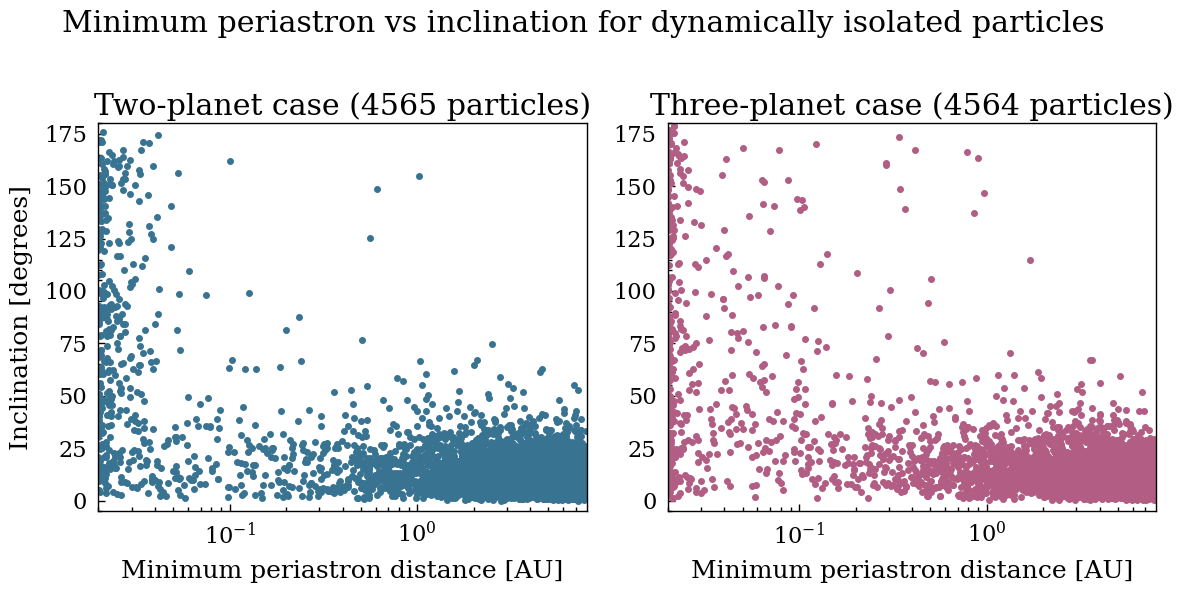

In [10]:
def plot_min_peri_vs_inc(all_particles_gas2, all_particles_gas3):
    all_peris_2 = all_particles_gas2[0]
    all_semimajors_2 = all_particles_gas2[1]
    all_incs_2 = np.degrees(all_particles_gas2[2])

    all_peris_3 = all_particles_gas3[0]
    all_semimajors_3 = all_particles_gas3[1]
    all_incs_3 = np.degrees(all_particles_gas3[2])

    #get the min of all mins in each file
    arg2, arg3 = np.argmin(all_peris_2), np.argmin(all_peris_3)
    min_semimajor2, min_semimajor3 = all_semimajors_2[arg2], all_semimajors_3[arg3]
    min_periastron2, min_periastron3 = all_peris_2[arg2], all_peris_3[arg3]
    min_inclination2, min_inclination3 = all_incs_2[arg2], all_incs_3[arg3]

    # for i in range(len(all_peris)):
    #     print(f"Peri: {all_peris[i]:.3f} AU, a: {all_semimajors[i]:.3f} AU, inc: {all_incs[i]:.2f} degrees")
    fig, ax = plt.subplots(1, 2, figsize=(12, 6)) 
    ax[0].plot(all_peris_2, all_incs_2, 'o', c="#397392", markersize=4, alpha=1)
    ax[1].plot(all_peris_3, all_incs_3, 'o', c="#B15D84", markersize=4, alpha=1)
    ax[0].set_xlabel('Minimum periastron distance [AU]')
    ax[0].set_ylabel('Inclination [degrees]')
    ax[1].set_xlabel('Minimum periastron distance [AU]')
    plt.suptitle('Minimum periastron vs inclination for dynamically isolated particles', y=1.0)
    ax[0].set_title(f'Two-planet case ({len(all_peris_2)} particles)')
    ax[1].set_title(f'Three-planet case ({len(all_peris_3)} particles)')
    #plt.grid()
    ax[0].set_xscale('log')
    ax[1].set_xscale('log')
    plt.tight_layout()
    for i in range(2):
        #ax[i].set_xlim(1e-2, 18)
        ax[i].set_ylim(-5, 180)
    plt.show()

    results = {
        'two_planet': {
            'min_periastron': min_periastron2,
            'min_semimajor': min_semimajor2,
            'all_peris': all_peris_2,
            'all_semis': all_semimajors_2
        },
        'three_planet': {
            'min_periastron': min_periastron3,
            'min_semimajor': min_semimajor3,
            'all_peris': all_peris_3,
            'all_semis': all_semimajors_3
        }
    }
    return results

results = plot_min_peri_vs_inc(all_ptcls_two_pl_1km, all_ptcls_two_pl_10km)
two_pl_results = results['two_planet']
three_pl_results = results['three_planet']

## 3) Calculate velocity of particle at periastron

In [2]:
def velocity_at_peri(a, peri):
    G = const.G
    M_star = const.M_sun * 0.965
    v_peri = np.sqrt(G * M_star * (2/(peri*u.AU) - 1/(a*u.AU)))
    return v_peri.to(u.m/u.s)

velocities, peris, semis = velocity_at_peri(three_pl_results['all_semis'], three_pl_results['all_peris']).to('km/s'), three_pl_results['all_peris'], three_pl_results['all_semis']

time_spend_at_peri = peris*u.AU/velocities

NameError: name 'three_pl_results' is not defined

### Calculate gas drag terms

In [ ]:
# ''' constants in AU, yr, M_sun units'''
# solid_rho = 1683721.7643842339
# sigma_char = 3.038845902395208e-07
# lg = 0.00841860882192117 
# kb = 3.0898292661510003e-61
# kb_si = const.k_B.value
# m_proton_si = const.m_p.value
# stellar_radius = 1.26 * const.R_sun.to('AU').value
# kgtomsun = (1 / const.M_sun).value
# dtor = np.pi / 180
# r_out = 40 
# mu = 2.33
# m_proton = 1.6726e-27 * kgtomsun
# G = const.G.to('AU**3 / (M_sun * yr**2)').value
# M_star = 0.965

# def get_GD_terms(peri, semi, r_pl):
#     '''first, compute gas density as a function of z'''

#     vx, vy, vz = velocity_at_peri(semi, peri).to(u.AU/u.yr).value, 0, 0
#     r = peri
#     print(r)
#     x, y, z = r, 0, 0

#     Omega = np.sqrt(G * M_star / r**3)

#     T = 38*(r/(40))**(-0.24)  #new temperature profile from pds 70 modelling papers
    
#     c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s
#     c_s = (c_s_si * u.m/u.s).to(u.AU/u.yr).value  # convert to AU/yr

#     H = c_s / Omega
#     print(c_s)
    
#     surface_density = sigma_char * (r/r_out)**(-1) * np.exp(-r/r_out) #pds 70 papers
    
#     if r>=18 and r<=40:
#         surface_density *= 0.01 # add a gap

#     if r<stellar_radius*3.4:
#         surface_density = 0 #no gas inside of 3.4 stellar radii - from pds 70 papers

#     gas_density = surface_density / (np.sqrt(2*np.pi) * H) * np.exp(-(z)**2 / (2 * H**2)) #from Eriksson+2021

#     'DEFINE GAS VELOCITY'
#     v_K = np.sqrt(G * M_star / r)

#     theta = np.arctan2(y,x)
#     theta = 0
#     v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0]) #trig to get correct direction

#     v_gas = v_K*v_unit_vector
#     v_pl_vector = np.array([vx, vy, vz]) #velocity of planetesimal

#     v_rel = v_pl_vector - v_gas 
#     v_rel_mag = np.linalg.norm(v_rel)

#     'calculate term in min func for stopping time - Eriksson+ 2021'
#     Re = 4 * r_pl * v_rel_mag / (c_s * lg)
#     C_D = 24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))

#     return gas_density, C_D, T, v_rel_mag

## Calculate gas drag terms in SI units

In [9]:
''' constants in AU, yr, M_sun units'''
solid_rho_si = 1000 * u.kg / u.m**3
sigma_char_si = 27 * u.kg / u.m**2
kb_si = const.k_B
m_proton_si = const.m_p
stellar_radius = 1.26 * const.R_sun.to('m') #876582000
dtor = np.pi / 180
r_out = (40 * u.AU).to(u.m)
mu = 2.33
#G = const.G.to('AU**3 / (M_sun * yr**2)').value
G = const.G
M_star = 0.96 * const.M_sun

def get_GD_terms(peri, semi, r_pl):
    '''first, compute gas density as a function of z'''

    vx, vy, vz = velocity_at_peri(semi, peri), 0*u.m/u.s, 0*u.m/u.s
    r = (peri*u.AU).to(u.m)
    x, y, z = (semi*u.AU).to(u.m), 0*u.m, 0*u.m

    Omega = np.sqrt(G * M_star / r**3)

    T = 38*(r/(r_out))**(-0.24) * u.K #new temperature profile from pds 70 modelling papers
    
    c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s
    #c_s = (c_s_si * u.m/u.s).to(u.AU/u.yr).value  # convert to AU/yr

    H = c_s_si / Omega

    
    surface_density = sigma_char_si * (r/r_out)**(-1) * np.exp(-r/r_out) #pds 70 papers
    
    # if(r.to('AU').value)>=18 and (r.to('AU').value)<=40:
    #     surface_density *= 0.01 # add a gap

    # if (r.to('AU').value)<(stellar_radius.to('AU').value)*3.4:
    #     surface_density = 0 #no gas inside of 3.4 stellar radii - from pds 70 papers

    midplane_gd = surface_density / (np.sqrt(2*np.pi) * H)
    gas_density = midplane_gd * np.exp(-(z.value)**2 / (2 * H.value**2)) #from Eriksson+2021
    'DEFINE GAS VELOCITY'
    v_K = np.sqrt(G * M_star / r)

    theta = np.arctan2(y,x)
    theta = 0
    v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0]) #trig to get correct direction

    #v_gas = v_K*v_unit_vector
    # v_pl_vector = np.array([vx.value, vy.value, vz.value]) * u.m/u.s #velocity of planetesimal
   
    # v_rel = v_pl_vector - v_gas 
    # v_rel_mag = np.linalg.norm(v_rel)

    v_rel_mag = np.abs(v_K - velocity_at_peri(semi, peri))

    'calculate term in min func for stopping time - Eriksson+ 2021'

    lg = 5e-6 * u.kg / (gas_density * u.m**3) * u.m #mean free path of gas molecules - from Eriksson+2021
    Re = 4 * r_pl * u.km * v_rel_mag / (c_s_si * lg)
    C_D = (24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))).to('')

    term_in_min =( 3/8*v_rel_mag/(np.sqrt(8/(np.pi))*c_s_si)).to('')
    
    return gas_density.to('M_sun/AU**3'), C_D, T, v_rel_mag.to('AU/yr')


In [4]:
mu_water = (18 * u.g/u.mol)
R_g = 8.314 * u.J / (u.mol * u.K)
sigma_sb = const.sigma_sb

def T_pl_dependent_terms(T_pl):
    L_w = 2.8e6 * u.J / u.kg
    T_pl = T_pl * u.K

    term3 = P_sat_vap(T_pl) / (sigma_sb) * np.sqrt(mu_water / (8*np.pi*R_g*T_pl)) * L_w

    return (term3 + T_pl**4).to('K4')
    
def T_pl_independent_terms(periastron, semimajor_axis, r_pl):

    gas_density, C_D, T, v_rel_mag = get_GD_terms(periastron, semimajor_axis, r_pl)

    term2 = C_D * gas_density * v_rel_mag**3 / (32 * sigma_sb)
    
    return (term2 + np.array(T.value)**4 * T.unit**4).to('K4')


In [9]:
r_pls = np.array([1, 10, 100]) 
GD_terms = [get_GD_terms(three_pl_results['all_peris'][2], three_pl_results['all_semis'][2], radpl) for radpl in r_pls]
print(GD_terms)
print(T_pl_independent_terms(three_pl_results['min_periastron'], three_pl_results['min_semimajor'], r_pls[1]))
print(T_pl_independent_terms(three_pl_results['all_peris'][:3], three_pl_results['all_semis'][:3], r_pls[0]))

NameError: name 'three_pl_results' is not defined

## Plot temperature intersection for ablation

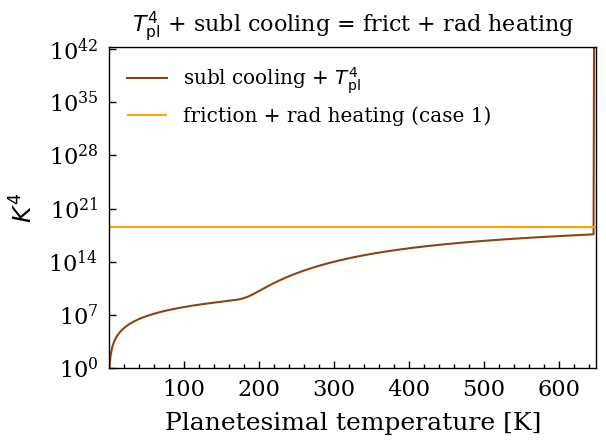

In [10]:
Ts = np.linspace(1, 650, 1000)

plt.plot(Ts, T_pl_dependent_terms(Ts), label=r'subl cooling + $T_\mathrm{pl}^4$', c='saddlebrown')
plt.hlines(T_pl_independent_terms(0.01, 2, 10).value, Ts[0], Ts[-1], label='friction + rad heating (case 1)', color='orange')

#plt.hlines(T_pl_independent_terms(three_pl_results['all_peris'][3], three_pl_results['all_semis'][3], r_pls[1]).value, Ts[0], Ts[-1], label='friction + rad heating (case 2)', color='orange')
#plt.plot(Ts, Ts**4, label=r'$T_\mathrm{pl}^4$', c='steelblue', linestyle='--')
# for i in range(400):
#     plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[-i]), c='orange', alpha=0.5)
#     #plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[-i]), c='orange')
#     if i == 0:
#         plt.plot(Ts, np.full_like(Ts, T_pl_independent_terms(sim)[i]), label=f'T_pl independent terms', c='orange')
#plt.ylim(1e0, 1e26)
plt.yscale('log')
plt.xlabel('Planetesimal temperature [K]')
plt.ylabel(r'$K^4$')
#plt.grid()
plt.legend(loc='upper left')
plt.title(r'$T_\mathrm{pl}^4$ + subl cooling = frict + rad heating', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import brentq

def solve_for_T_pl(peri, semi, r_pl, T_range = (1, 800)):

    ind = T_pl_independent_terms(peri, semi, r_pl)
    def diff(T):
        return T_pl_dependent_terms(T).value - ind.value
    
    T_solution = brentq(diff, T_range[0], T_range[1])
    return T_solution


T_solutions = [solve_for_T_pl(three_pl_results['all_peris'][3], three_pl_results['all_semis'][3], r_pl) for r_pl in r_pls]

print("T_pl solutions:", T_solutions)

## Reproduce Fig. D.1 from Eriksson 2021 - ablation rate vs semimajor axis 

In [ ]:
print(r_pls)

def ablation_rate(r_pl, T_pl):
    mu_water = 18 * u.g/u.mol
    R_g = 8.314 * u.J / (u.mol * u.K)
    T_pl = T_pl * u.K
    mass_ablation = -4 * np.pi * (r_pl*u.km)**2 * P_sat_vap(T_pl) * np.sqrt(mu_water / (2*np.pi*R_g*T_pl))
    
    return mass_ablation.to('kg/yr')

print(ablation_rate(r_pls[1], 400))

In [12]:
def ablation_vs_semimajor_axis(peris, semis, r_pl, factor=1, paper_method=True, paper_temp_profile=True):

    ablation_rates = []
   
    #T_solution = solve_for_T_pl(p, a, r_pl)
    if paper_method:
        for a in semis:
            #T = 150 * (a)**(-3/7)
            if paper_temp_profile:
                T = 150 * (a)**(-3/7)
            else:
                T = 38*(a/(40))**(-0.24) #new temperature profile from pds 70 modelling papers
            dm_dt = ablation_rate(r_pl, T*factor)
            ablation_rates.append(-dm_dt.value)

    else:
        for p, a in zip(peris, semis):
            T = solve_for_T_pl(p, a, r_pl)
            dm_dt = ablation_rate(r_pl, T*factor)
            ablation_rates.append(-dm_dt.value)

    ablation_rates = np.array(ablation_rates)

    return ablation_rates*u.kg/u.yr



### mass from radius of planetesimal

In [13]:
def mass_from_radius(radius):
    return 1000 * u.kg / u.m**3 * ((radius*u.km).to(u.AU))**3 * 2/3 * np.pi

print(mass_from_radius(100).to('kg'))

2.094395102393195e+18 kg


In [ ]:
ablation_rates_from_data_three_pl_1km = ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False)
ablation_rates_from_data_three_pl_10km = ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[1], factor=1, paper_method=False)
ablation_rates_from_data_three_pl_100km = ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[2], factor=1, paper_method=False)


In [ ]:
print(len(ablation_rates_from_data_three_pl_1km))

In [ ]:
ablation_rates_from_data_two_pl_1km = ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False)
ablation_rates_from_data_two_pl_10km = ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[1], factor=1, paper_method=False)
ablation_rates_from_data_two_pl_100km = ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[2], factor=1, paper_method=False)


In [14]:
mass_ablated_per_passage_data_three_pl_1km = ablation_rates_from_data_three_pl_1km * time_spend_at_peri
mass_ablated_per_passage_data_three_pl_10km = ablation_rates_from_data_three_pl_10km * time_spend_at_peri
mass_ablated_per_passage_data_three_pl_100km = ablation_rates_from_data_three_pl_100km * time_spend_at_peri

number_of_passages_needed_1km = (mass_from_radius(r_pls[0]) / mass_ablated_per_passage_data_three_pl_1km).to('')
number_of_passages_needed_10km = (mass_from_radius(r_pls[1]) / mass_ablated_per_passage_data_three_pl_10km).to('')
number_of_passages_needed_100km = (mass_from_radius(r_pls[2]) / mass_ablated_per_passage_data_three_pl_100km).to('')

fig, ax = plt.subplots(figsize=(8, 8))
plt.plot(three_pl_results['all_semis'][:], number_of_passages_needed_100km, 'o', markersize=3, c='purple', label='100 km radius')
plt.plot(three_pl_results['all_semis'][:], number_of_passages_needed_10km, 'o', markersize=3, c='palevioletred', label='10 km radius')
plt.plot(three_pl_results['all_semis'][:], number_of_passages_needed_1km, 'o', markersize=3, c='plum', label='1 km radius')

plt.xlabel('Semi-major Axis (AU)')
plt.ylabel('N periastron passages for complete ablation')
plt.title('Ablation Rates')
plt.xlim(0, 25)
plt.yscale('log')
plt.legend(loc='upper left')
#plt.ylim(1, 1e8)
#plt.yscale('log')
plt.show()


NameError: name 'ablation_rates_from_data_three_pl_1km' is not defined

In [ ]:
print(np.argmax(two_pl_results['all_semis']))
print(two_pl_results['all_peris'][128])

NameError: name 'ablation_vs_semimajor_axis' is not defined

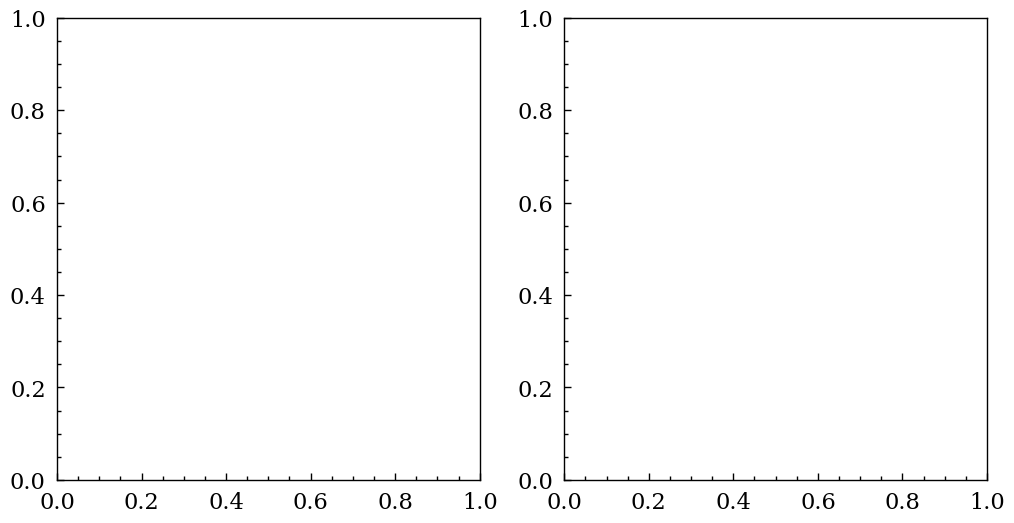

In [11]:
semis = np.linspace(0.1, 100, 1000)
fig, ax = plt.subplots(1, 2, figsize=(12,6))
# ax[0].plot(three_pl_results['all_semis'][:],
#            ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[0], factor=2, paper_method=True),
#            'o', markersize=4, label='Three planet case')
# ax[1].plot(two_pl_results['all_semis'][:],
#            ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False),
#            'o', markersize=4, label='Two planet case')

ax[0].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=1), c='steelblue', label=r'$T_\mathrm{pl} = 1 \times T$')
ax[0].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=2), linestyle='--', c='steelblue', label=r'$T_\mathrm{pl} = 2 \times T$')

ax[1].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=1, paper_temp_profile=False), c='steelblue', label=r'$T_\mathrm{pl} = 1 \times T$')
ax[1].plot(semis, ablation_vs_semimajor_axis(peris, semis, r_pls[0], factor=2, paper_temp_profile=False), linestyle='--', c='steelblue', label=r'$T_\mathrm{pl} = 2 \times T$')


ax[0].set_ylabel('ablation rate [kg/yr]')
ax[0].set_title('Using Eriksson+2021 disc temp profile', fontsize=18)
ax[1].set_title('Using Bae+2019 disc temp profile', fontsize=18)
# ax[0].set_ylim(1, 1e25)
for i in range(2):
    ax[i].plot(three_pl_results['all_peris'][:],
           ablation_vs_semimajor_axis(three_pl_results['all_peris'][:], three_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False),
           'o', markersize=4, label='Three planet case')
    ax[i].plot(two_pl_results['all_peris'][:],
           ablation_vs_semimajor_axis(two_pl_results['all_peris'][:], two_pl_results['all_semis'][:], r_pls[0], factor=1, paper_method=False),
           'o', markersize=4, label='Two planet case')

    ax[i].legend(loc='lower left')
    ax[i].set_yscale('log')
    ax[i].set_xscale('log')
    ax[i].set_xlabel('semimajor axis  [AU]')
    ax[i].set_xlim(0.5, 50)
    ax[i].set_ylim(1e-30, 1e30)
    
# ax[0].set_ylim(1, 1e25)
# ax[1].set_ylim(1e-5, 1e17)
#ax[0].set_xlim(1, 800)
plt.tight_layout()
plt.show()

In [ ]:
new_Ts = np.linspace(100, 600, 1000)

for i in range(3):
    line, = plt.plot(new_Ts, -ablation_rate(r_pls[i], new_Ts).to('kg/yr').value,
        label=f'{(r_pls[i]):.0f} km'
    )

    color = line.get_color()

    plt.hlines(mass_from_radius(r_pls[i]).to('kg').value, new_Ts[0], new_Ts[-1], linestyle=':',
               color=color)

from matplotlib.lines import Line2D

custom_line = Line2D(
    [0], [0],
    color='black',
    linestyle=':',
    label='initial mass'
)

plt.legend(handles=plt.gca().get_legend_handles_labels()[0] + [custom_line],
           labels=plt.gca().get_legend_handles_labels()[1] + ['initial mass'])

plt.yscale('log')
plt.ylabel('Ablation rate [kg/yr]')
plt.xlabel('Planetesimal temperature [K]')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
new_Ts = np.linspace(100, 600, 1000)

taus = [-ablation_rate(r_pls[i], new_Ts).to('kg/yr').value/mass_from_radius(r_pls[i]).to('kg').value for i in range(3)]
for i in range(3):
    tau = -ablation_rate(r_pls[i], new_Ts).to('kg/yr').value/mass_from_radius(r_pls[i]).to('kg').value
    line, = plt.plot(new_Ts, tau,
        label=f'{(r_pls[i]):.0f} km'
    )

    color = line.get_color()

from matplotlib.lines import Line2D


plt.legend()

plt.yscale('log')
plt.ylabel(r'$\dot{M}/M$  [yr$^{-1}$]')
plt.xlabel('Planetesimal temperature [K]')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
m = 1000 * u.kg / u.m**3 * (100 * u.km)**3 * 2/3 * np.pi
print(f'{m.to('kg'):.2e}')

# When is C_D term in min_function (stopping time) relevant?

basically we need low v_rel_mag and high speed of sound (aka temp). But more importantly, high v_rel_mag, since it only depends on T**(1/2)

In [ ]:
def C_D_term_in_min_func():

    v_K = np.sqrt(G * M_star / (peris*u.AU))

    T = 38*(peris/(40))**(-0.24) * u.K #new temperature profile from pds 70 modelling papers


    v_rel_mag = np.abs(velocities - v_K)
    c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s

    return v_rel_mag, (0.47* 3/8*v_rel_mag/(np.sqrt(8/(np.pi))*c_s_si)).to('')



# print(C_D_term_in_min_func(v_rels, 400))
# print(C_D_term_in_min_func(v_rels, 30))
plt.plot(peris, C_D_term_in_min_func()[1], 'o', markersize=4)
plt.axhline(y=1, linestyle='--', color='navy', label='term = 1')
plt.yscale('log')
plt.xscale('log')
plt.ylim(0.1, 50)
plt.legend()
plt.xlabel('distance [AU]')
plt.ylabel('term in stopping time func')
plt.show()

the answer is, it's relevant for very low relative velocities, that is, high periastrons. I don't know why there is an outlier.

# Method 2 - from orbits of star-grazers

## 1) extract what we need from sim output to reconstruct orbit

In [11]:
import os, re, glob
import numpy as np
import netCDF4
from netCDF4 import Dataset
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def get_sg_properties(filename):
    """Single-pass: validate + extract in one file open."""
    try:
        with netCDF4.Dataset(filename, 'r') as ncfile:
            # --- validation (was filter_valid_netcdf_files) ---
            if 'star_grazed' not in ncfile.variables:
                return None
            if ncfile['star_grazed'].size == 0:
                return None
            if 'massive_bodies' not in ncfile.variables:
                return None

            mb = ncfile['massive_bodies']
            if mb.shape[0] == 0:
                return None

            last = mb.shape[0] - 1

            # ✅ Only read the slices you need, not the whole array
            ple = mb[:, :, 4]   # still full time axis, but only 1 variable
            pla = mb[:, :, 5]
            # last-row scalars for tf (if needed downstream)
            # tf = mb[last, 0, 0] / 5  # uncomment if needed

            apo_dist_b  = pla[:, 1] * (1 + ple[:, 1])
            peri_dist_c = pla[:, 2] * (1 - ple[:, 2])

            if not (np.all(ple < 1) and
                    np.all(apo_dist_b < peri_dist_c) and
                    np.all(pla < 87)):
                return None

            star_grazers = ncfile['star_grazed'][:].filled(np.nan)
            for ptcl in star_grazers:
                if ptcl[1]**2 + ptcl[2]**2 + ptcl[3]**2 < 25:  # 5² = 25
                    return ptcl

    except Exception:
        return None

    return None


def combine_all_star_grazers(filenames, label=""):
    with ProcessPoolExecutor(max_workers=30) as executor:
        results = list(tqdm(
            executor.map(get_sg_properties, filenames, chunksize=16),
            total=len(filenames),
            desc=f"processing {label}"
        ))
    return [r for r in results if r is not None and len(r) > 0]


def get_core_number(filename):
    m = re.search(r'core_(\d+)_', os.path.basename(filename))
    return int(m.group(1)) if m else -1


sorted_with_gas_2_pl_1km   = sorted(glob.glob('core_outputs_yr2/gas_drag_final/*1km*.nc'),   key=get_core_number)
sorted_with_gas_2_pl_10km  = sorted(glob.glob('core_outputs_yr2/gas_drag_final/*10km*.nc'),  key=get_core_number)
sorted_with_gas_2_pl_100km = sorted(glob.glob('core_outputs_yr2/gas_drag_final/*100km*.nc'), key=get_core_number)

all_grazers_2pl_1km   = combine_all_star_grazers(sorted_with_gas_2_pl_1km,   "1km")
all_grazers_2pl_10km  = combine_all_star_grazers(sorted_with_gas_2_pl_10km,  "10km")
all_grazers_2pl_100km = combine_all_star_grazers(sorted_with_gas_2_pl_100km, "100km")

processing 100km: 100%|██████████| 7638/7638 [09:20<00:00, 13.62it/s] 


## What do inclinations of star-grazers look like as a function of periastron?

In [60]:
hashes = []
for particle in all_grazers_2pl_1km:
    inc = particle[6]
    if np.degrees(inc) > 40:
        hashes.append(particle[-1])

results = {}  # {hash: {1: array, 10: array, 100: array}}

for h in hashes[:500]:
    size_data = {}
    for size in [1, 10, 100]:
        matches = glob.glob(f'core_outputs_yr2/gas_drag_final/*{int(h)}*_particle_{size}km*')
        if not matches:
            continue
        with netCDF4.Dataset(matches[0], 'r') as ncfile:
            if 'star_grazed' not in ncfile.variables:
                continue
            if ncfile['star_grazed'].size == 0:
                continue
            size_data[size] = ncfile['test_particles'][:, :7]

    if len(size_data) == 3:
        results[int(h)] = size_data

print(len(results))

20


[11793104, 41660026, 46890026, 7714210, 26827210, 4086009, 36133215, 3655037, 49578013, 7512013]


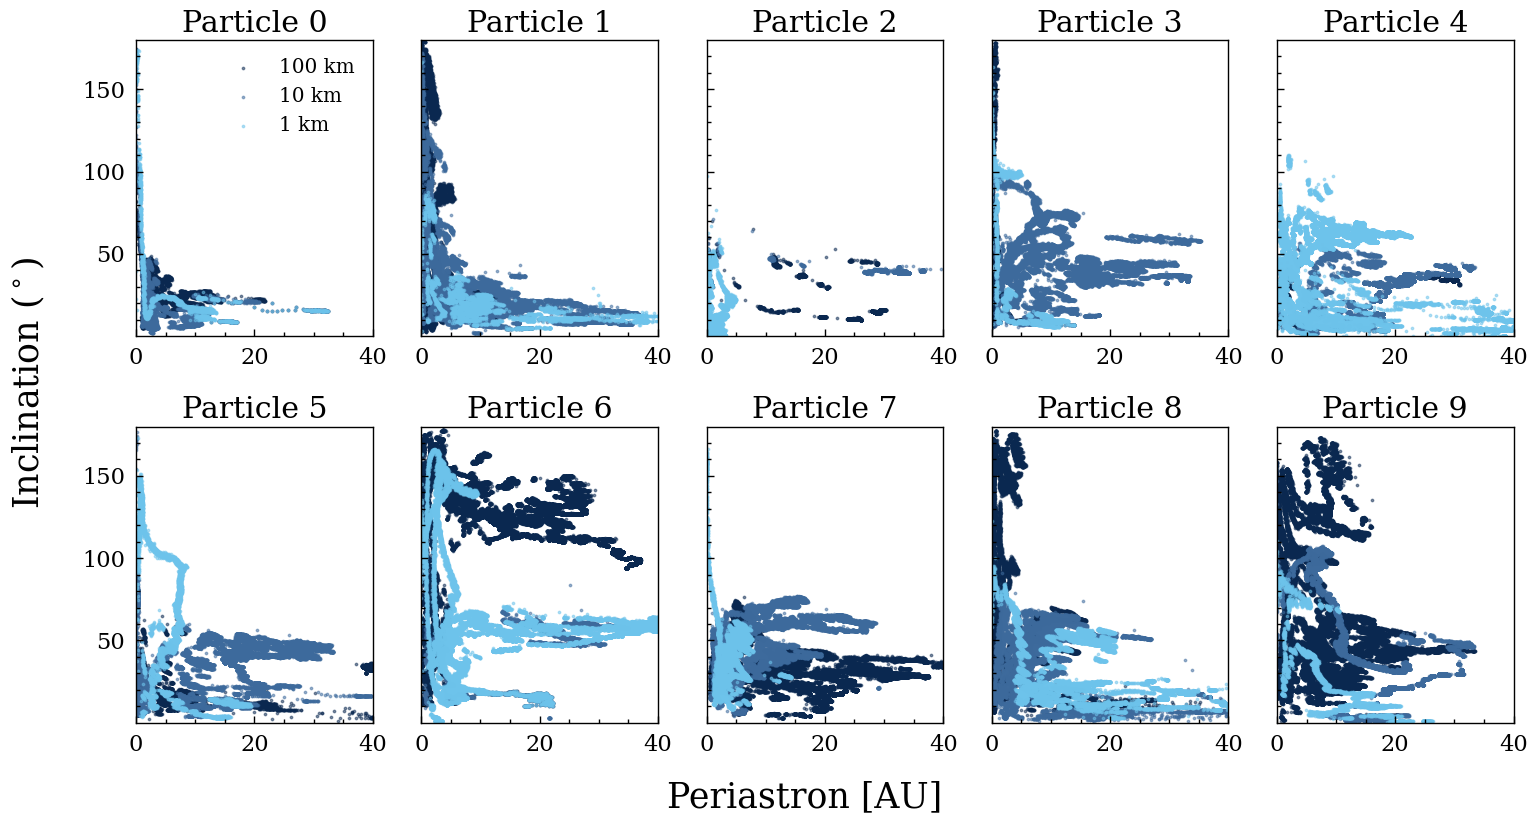

In [79]:
sample_hashes = list(results.keys())[:10]
print(sample_hashes)
sizes = [100, 10, 1]
#colors = {1: 'steelblue', 10: 'darkorange', 100: 'seagreen'}

fig, axes = plt.subplots(2, int(len(sample_hashes)/2), figsize=(15, 8), sharey=True)
colors = {10: "#3D6A9C", 100: "#0A2850", 1: "#6dc3eb" }

count = 0
axes = axes.ravel()
for ax, h in zip(axes, sample_hashes):

    for size in sizes:
        if size not in results[h]:
            print('skipped')
            continue
        ptcl = results[h][size]
        a = ptcl[:, 5]
        e = ptcl[:, 4]
        inc = np.degrees(ptcl[:, 6])
        periastron = a * (1 - e)
        ax.scatter(periastron, inc, s=3, alpha=0.5, label=f'{size} km', color=colors[size])
    ax.set_title(f'Particle {count}')
    #ax.set_xlabel('periastron (AU)')
    ax.set_xlim(0, 40)
    count += 1

# axes[0].set_ylabel(r'inclination ($^\circ$)')
# axes[5].set_ylabel(r'inclination ($^\circ$)')
fig.text(-0.03, 0.5, r'Inclination ($^\circ$)', va='center', rotation=90, fontsize=25)
fig.text(0.5, -0.03, 'Periastron [AU]', ha='center', rotation=0, fontsize=25)
axes[0].legend()
plt.tight_layout()
plt.show()

In [33]:
print(results[hashes[0]][1])

for pl_size in [1, 10, 100]:
    inc = results[hashes[0]][pl_size][:,6]

[[ 0.00000000e+00  1.70382254e+01  5.79640993e+00  7.05150304e-02
   3.10735128e-01  2.14336804e+01]
 [ 1.00000020e+01  3.14604091e+00  1.47031555e+01  1.30664631e+00
   3.02958719e-01  2.15382514e+01]
 [ 2.00000040e+01 -1.33893169e+01  9.87827209e+00  1.31068483e+00
   3.28377848e-01  2.24025198e+01]
 ...
 [ 9.99970200e+05 -3.65510356e+00  2.23282763e+00  3.59748614e-02
   4.36490918e-02  4.22896280e+00]
 [ 9.99980200e+05 -4.21517667e+00 -2.13709154e-01  2.87170046e-02
   4.97527992e-02  4.10147197e+00]
 [ 9.99990200e+05 -3.30193359e+00 -2.53189960e+00  1.31515400e-02
   5.59213031e-02  3.98586789e+00]]


IndexError: index 6 is out of bounds for axis 1 with size 6

In [23]:
file = f'core_outputs_yr2/gas_drag_final/*{hashes[0]}*'
print(file)

core_outputs_yr2/gas_drag_final/*33215005.0*


## 2) Use Jaxoplanet to reconstruct orbit

Note the units we need:

- lengths in R_sun
- masses in M_sun
- times in days
- angles in radians

In [12]:
import jax.numpy as jnp
import exoplanet as exo
import astropy.units as u
from jaxoplanet.orbits.keplerian import System, Central, Body, OrbitalBody
from scipy.optimize import brentq

def get_orbits(files):
    all_particles = {}
    for index, particle in enumerate(files):
        key = index
        star = Central(radius=1.26, mass=0.965)
        system = System(star).add_body(
            eccentricity = particle[4],
            semimajor = (particle[5]*(u.au)).to(u.R_sun).value,
            inclination = particle[6],
            asc_node = particle[8],
            omega_peri = particle[9],
            time_peri = 0
        )
        period = (system.bodies[0].period*u.d).value
        period_in_yrs = (system.bodies[0].period*u.d).to(u.yr)
        body = system.bodies[0]
        t = jnp.linspace(0, period, 10000) 
        pos = body.relative_position(t)
        vel = body.central_velocity(t)
        all_particles[key] = {
            'x': np.array(pos[0]),
            'y': np.array(pos[1]),
            'z': np.array(pos[2]),
            'vx': np.array(vel[0]),
            'vy': np.array(vel[1]),
            'vz': np.array(vel[2]),
            't': t,
            'inc': particle[6]
        }
    return all_particles


/data/ally/my_env/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [13]:

cartesian_params_1km = get_orbits(all_grazers_2pl_1km)
print('done 1')
cartesian_params_10km = get_orbits(all_grazers_2pl_10km)
print('done 2')
cartesian_params_100km = get_orbits(all_grazers_2pl_100km)


done 1
done 2


In [ ]:
# %matplotlib widget

# plt.close()
# for i in range(7):
#     fig, ax = plt.subplots()
#     x = cartesian_params_10km[i]['x'] * const.R_sun.to(u.AU)
#     y = cartesian_params_10km[i]['y'] * const.R_sun.to(u.AU)
#     z = cartesian_params_10km[i]['z'] * const.R_sun.to(u.AU)
#     t = cartesian_params_10km[i]['t']
#     r = np.sqrt(x**2 + y**2 + z**2)
#     ax.plot(t, r)
#     plt.grid(alpha=0.5)
#     plt.show()

In [ ]:
# %matplotlib widget

# plt.close()
# for i in range(4):
#     ax = plt.figure().add_subplot(projection='3d')

#     x = cartesian_params_10km[i+6]['x'] * const.R_sun.to(u.AU)
#     y = cartesian_params_10km[i+6]['y'] * const.R_sun.to(u.AU)
#     z = cartesian_params_10km[i+6]['z'] * const.R_sun.to(u.AU)
#     ax.plot(x, y, z, zdir='z', label='curve in (x, y)')
#     ax.set_title(f'inc {np.degrees(cartesian_params_10km[i+6]['inc']):.2f}')
#     plt.grid(alpha=0.5)
#     ax.set_xlabel('x [AU]')
#     ax.set_ylabel('y [AU]')
#     ax.set_zlabel('z [AU]')
#     plt.show()

## slow version

In [14]:
def get_ablation(x, y, z, vx, vy, vz, r_pl):

    ''' constants in SI units'''
    sigma_char_si = 27 * u.kg / u.m**2
    kb_si = const.k_B
    m_proton_si = const.m_p
    stellar_radius = 1.26 * const.R_sun.to('m') #876582000
    r_out = (40 * u.AU).to(u.m)
    mu = 2.33
    #G = const.G.to('AU**3 / (M_sun * yr**2)').value
    G = const.G
    M_star = 0.96 * const.M_sun

    '''first, compute gas density as a function of z'''

    vx, vy, vz = (vx*u.R_sun/u.day).to(u.m/u.s), (vy*u.R_sun/u.day).to(u.m/u.s), (vz*u.R_sun/u.day).to(u.m/u.s)
    x, y, z = (x*u.R_sun).to(u.m), (y*u.R_sun).to(u.m), (z*u.R_sun).to(u.m)

    r = np.sqrt(x**2 + y**2 + z**2)
    print(r)

    Omega = np.sqrt(G * M_star / r**3)

    T = 38*(r/(r_out))**(-0.24) * u.K #new temperature profile from pds 70 modelling papers
    c_s_si = np.sqrt(kb_si * T / (mu * m_proton_si))  # m/s
    #c_s = (c_s_si * u.m/u.s).to(u.AU/u.yr).value  # convert to AU/yr

    H = c_s_si / Omega

    surface_density = sigma_char_si * (r/r_out)**(-1) * np.exp(-r/r_out) #pds 70 papers
    
    if(r.to('AU').value)>=18 and (r.to('AU').value)<=40:
        surface_density *= 0.01 # add a gap

    if (r.to('AU').value)<(stellar_radius.to('AU').value)*3.4:
        surface_density = 0 #no gas inside of 3.4 stellar radii - from pds 70 papers

    midplane_gd = surface_density / (np.sqrt(2*np.pi) * H)

    gas_density = midplane_gd * np.exp(-(z.value)**2 / (2 * H.value**2)) #from Eriksson+2021
    
    if gas_density.value < 1e-40:
        return 0 * u.kg/u.yr
    
    'DEFINE GAS VELOCITY'
    v_K = np.sqrt(G * M_star / r)

    theta = np.arctan2(y,x)
    v_unit_vector = np.array([-np.sin(theta), np.cos(theta), 0]) #trig to get correct direction

    v_gas = v_K*v_unit_vector
    v_pl_vector = np.array([vx.value, vy.value, vz.value]) * u.m/u.s #velocity of planetesimal
   
    v_rel = v_pl_vector - v_gas 
    v_rel_mag = np.linalg.norm(v_rel)

    'calculate term in min func for stopping time - Eriksson+ 2021'

    lg = 5e-6 * u.kg / (gas_density * u.m**3) * u.m #mean free path of gas molecules - from Eriksson+2021
    Re = 4 * r_pl * v_rel_mag / (c_s_si * lg)

    C_D = (24/Re * (1+0.27*Re)**(0.43) + 0.47*(1-np.exp(-0.04*Re**(0.38)))).to('')

    #print(C_D.to(''), 'gas density', gas_density.to('kg/m^3'))

    term_in_min =( 3/8*v_rel_mag/(np.sqrt(8/(np.pi))*c_s_si)).to('')
    
    mu_water = (18 * u.g/u.mol)
    R_g = 8.314 * u.J / (u.mol * u.K)
    sigma_sb = const.sigma_sb
    L_w = 2.8e6 * u.J / u.kg

    def T_pl_dependent_terms(T_pl):
        T_pl = T_pl * u.K

        term3 = P_sat_vap(T_pl) / (sigma_sb) * np.sqrt(mu_water / (8*np.pi*R_g*T_pl)) * L_w

        return (term3 + T_pl**4).to('K4')
        
    def solve_for_T_pl(T_range = (1, 1000)):

        term2 = C_D * gas_density * v_rel_mag**3 / (32 * sigma_sb)

        ind = (term2 + np.array(T.value)**4 * T.unit**4).to('K4')
        
        def diff(T):
            return T_pl_dependent_terms(T).value - ind.value
        
        T_solution = brentq(diff, T_range[0], T_range[1])
        return T_solution

    T_pl = solve_for_T_pl() * u.K

    mass_ablation = 4 * np.pi * (r_pl)**2 * P_sat_vap(T_pl) * np.sqrt(mu_water / (2*np.pi*R_g*T_pl))
    
    return mass_ablation.to('kg/yr')

r_pls = np.array([1, 10, 100]) * u.km


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
import astropy.units as u

def compute_single_particle(args):
    """Worker function — one particle per call."""
    particle, r_pl_km = args
    r_pl = r_pl_km * u.km

    x  = np.array(particle['x'])
    y  = np.array(particle['y'])
    z  = np.array(particle['z'])
    vx = np.array(particle['vx'])
    vy = np.array(particle['vy'])
    vz = np.array(particle['vz'])
    t  = np.array(particle['t'])

    rates = np.zeros(len(t))  # default to 0 (no ablation)

    for i in range(len(t)):
        try:
            dm_dt = get_ablation(x[i], y[i], z[i], vx[i], vy[i], vz[i], r_pl)
            rates[i] = dm_dt.to('kg/yr').value
        except Exception:
            rates[i] = 0.0

    total_mass_loss = 0.0
    for i in range(len(t) - 1):
        dt = t[i+1] - t[i]
        if not np.isnan(rates[i]):
            total_mass_loss += rates[i] * dt
        else:
            print('added none')
        return {
            'total_loss_kg': total_mass_loss,
            'rates_kg_yr':   rates,
            't':             t,
            'inc':           particle['inc'],
        }


def run_parallel_ablation(particles, r_pl_km, n_workers=None):
    """
    Run ablation computation in parallel, one worker per particle.
    
    Parameters
    ----------
    particles : list of orbit dicts (each with x,y,z,vx,vy,vz,t,inc)
    r_pl_km   : float — planetesimal radius in km (passed as plain float to avoid
                pickle issues with astropy Quantities across processes)
    n_workers : int or None — defaults to number of particles (one core each)
    
    Returns
    -------
    list of result dicts
    """
    args = [(p, r_pl_km) for p in particles]
    n_workers = n_workers or len(particles)

    with Pool(processes=n_workers) as pool:
        results = pool.map(compute_single_particle, args)

    return results


# ── run and plot ───────────────────────────────────────────────────────────────

if __name__ == '__main__':      # required guard for multiprocessing on all platforms
    r_pl_km = 100.0             # pass as plain float — reconstruct inside worker

    particle_list = [cartesian_params_100km[i] for i in range(8)]
    results = run_parallel_ablation(particle_list, r_pl_km, n_workers=5)

    for res in results:
        fig, ax = plt.subplots()
        ax.plot(res['t'], res['rates_kg_yr'])
        ax.set_ylim(6.3e-15, 5e18)
        ax.set_yscale('log')
        ax.text(0.1, 1e10, f"total loss = {res['total_loss_kg']:.2e} kg")
        ax.set_title(f"inclination = {np.degrees(res['inc']):.2f} deg")
        ax.set_xlabel('time [yr]')
        ax.set_ylabel('dM/dt [kg/yr]')
        plt.show()

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


55554102648.12171 m55276268593.87703 m58451356115.14013 m52673194008.414665 m57394465012.34836 m




55277164718.16672 m55564458269.14307 m

58462716945.9119 m
57395579532.66765 m54619017217.425 m

55279852966.98454 m55595509281.139465 m

58496781313.91764 m59959452226.45167 m

55647208235.41018 m57398922909.612076 m

55284332968.24931 m67637248572.32977 m

58553494970.78212 m
55719476397.55963 m
76683451958.93117 m
57404494591.27016 m
55290604102.0677 m86444975842.02226 m
55812204262.20804 m

58632767915.77612 m
96533711765.19179 m
57412293658.21828 m55925252262.8378 m

55298665501.09659 m106729145778.36554 m

58734475008.89446 m
116907747836.01146 m
57422318824.163345 m56058451666.37094 m

55308516051.05011 m127000977233.98985 m

58858456815.825645 m136971626918.96236 m

57434568436.84103 m56211605639.57054 m
146800568642.99664 m
55320154391.35003 m

59004520671.915794 m156479230148.34372 m

57449040479.16826 m
166005245218.99667 m56384490472.18696 m55333578915.91905 m


59172441949.

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Process ForkPoolWorker-139:
Process ForkPoolWorker-140:
Exception ignored in: Process ForkPoolWorker-141:
Process ForkPoolWorker-143:
<function _xla_gc_callback at 0x7dbfe43e8860>
Traceback (most recent call last):


KeyboardInterrupt: 

## speeding up the computations

In [ ]:
#this function works the best

def get_ablation_vectorized(particle_data, r_pl):
    """
    Compute dm/dt at all timesteps, skipping zero-ablation points early.
    Returns total mass loss over one orbit.
    """
    x  = particle_data['x']
    y  = particle_data['y']
    z  = particle_data['z']
    vx = particle_data['vx']
    vy = particle_data['vy']
    vz = particle_data['vz']
    t  = np.array(particle_data['t'])

    # --- unit conversions done once, outside the loop ---
    x_m  = (x  * u.R_sun).to(u.m).value
    y_m  = (y  * u.R_sun).to(u.m).value
    z_m  = (z  * u.R_sun).to(u.m).value
    vx_m = (vx * u.R_sun / u.day).to(u.m / u.s).value
    vy_m = (vy * u.R_sun / u.day).to(u.m / u.s).value
    vz_m = (vz * u.R_sun / u.day).to(u.m / u.s).value
    t_yr = (t  * u.day).to(u.yr).value

    # --- constants (all SI, computed once) ---
    sigma_char  = 27.0                           # kg/m^2
    kb          = const.k_B.value               # J/K
    m_p         = const.m_p.value               # kg
    G           = const.G.value                 # SI
    M_star      = (0.96 * const.M_sun).value    # kg
    R_star      = (1.26 * const.R_sun).value    # m
    r_out       = (40 * u.AU).to(u.m).value     # m
    mu          = 2.33
    mu_water    = 18e-3 / 6.022e23              # kg/molecule
    mu_water_mol= 18e-3                          # kg/mol
    R_g         = 8.314                         # J/mol/K
    sigma_sb    = const.sigma_sb.value          # W/m^2/K^4
    L_w         = 2.8e6                         # J/kg
    r_pl_m      = r_pl.to(u.m).value

    n = len(t)
    dm_dt = np.zeros(n)  # kg/yr

    for i in range(n):
        xi, yi, zi = x_m[i], y_m[i], z_m[i]
        r = np.sqrt(xi**2 + yi**2 + zi**2)
        r_au = r / 1.496e11

        # --- early exit: no gas inside 3.4 R_star ---
        if not np.isfinite(r) or r < R_star * 3.4:
            continue

        # --- gas density ---
        T_gas   = 38 * (r / r_out)**(-0.24)          # K
        c_s     = np.sqrt(kb * T_gas / (mu * m_p))   # m/s
        Omega   = np.sqrt(G * M_star / r**3)
        H       = c_s / Omega
        sig     = sigma_char * (r / r_out)**(-1) * np.exp(-r / r_out)
        if 18 <= r_au <= 40:
            sig *= 0.01
        rho0    = sig / (np.sqrt(2 * np.pi) * H)
        rho_gas = rho0 * np.exp(-zi**2 / (2 * H**2))

        if rho_gas < 1e-40:
            continue

        # --- relative velocity ---
        vxi, vyi, vzi = vx_m[i], vy_m[i], vz_m[i]
        v_K   = np.sqrt(G * M_star / r)
        theta = np.arctan2(yi, xi)
        vgx, vgy = -v_K * np.sin(theta), v_K * np.cos(theta)
        dvx, dvy, dvz = vxi - vgx, vyi - vgy, vzi
        v_rel = np.sqrt(dvx**2 + dvy**2 + dvz**2)

        # --- drag coefficient ---
        lg   = 5e-6 / (rho_gas)                      # mean free path, m
        Re   = 4 * r_pl_m * v_rel / (c_s * lg)
        C_D  = (24/Re * (1 + 0.27*Re)**0.43
                + 0.47 * (1 - np.exp(-0.04 * Re**0.38)))

        # --- solve for T_pl ---
        def P_sat_vap(T_pl):

            Pc =22.065e6
            Tc = 647.096 #Kelvin

            T_pl = np.asarray(T_pl, dtype=float)
            P_sat = np.full_like(T_pl, 1e32, dtype=float)
            mask = T_pl < Tc
            T_pl_valid = T_pl[mask]

            theta = T_pl_valid / Tc
            tau = 1 - theta
            a1, a2, a3, a4, a5, a6 = -7.85951783, 1.84408259, -11.7866497, 22.6807411, -15.9618719, 1.80122502
            log_p_over_pc = Tc/T_pl_valid * (a1*tau + a2*tau**1.5 + a3*tau**3 + a4*tau**3.5 + a5*tau**4 + a6*tau**7.5)

            P_sat[mask] = np.exp(log_p_over_pc) * Pc
            
            return P_sat

        ind = C_D * rho_gas * v_rel**3 / (32 * sigma_sb) + T_gas**4

        def residual(T_pl):
            p    = P_sat_vap(T_pl)
            term = p / sigma_sb * np.sqrt(mu_water_mol / (8 * np.pi * R_g * T_pl)) * L_w
            return term + T_pl**4 - ind

        try:
            T_pl = brentq(residual, 1, 600)
        except ValueError:
            continue

        # --- ablation rate ---
        p_sat  = P_sat_vap(T_pl)
        dm_si  = (4 * np.pi * r_pl_m**2 * p_sat
                  * np.sqrt(mu_water / (2 * np.pi * kb * T_pl)))  # kg/s
        dm_dt[i] = (dm_si * u.kg / u.s).to(u.kg / u.yr).value
        
        if dm_dt[i] == 0:
            dm_dt[i] = np.nan
    
    dt = np.diff(t_yr)
    total = np.sum(dm_dt[:-1] * dt)
    
    return dm_dt, total  # kg


def _worker(args):
    key, pdata, r_pl = args  # r_pl is a single value now, not a list
    total = get_ablation_vectorized(pdata, r_pl)
    return key, total


def integrate_particle_set(all_particles, r_pl, max_workers=8):
    """Run for one set of particles all sharing the same r_pl."""
    args = [(key, pdata, r_pl) for key, pdata in all_particles.items()]
    results = {}
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for key, total in tqdm(executor.map(_worker, args),
                               total=len(args), desc=f"r_pl={r_pl}"):
            results[key] = total
    return results

#r_pls = np.array([1, 10, 100]) * u.km


In [40]:
results_1km   = integrate_particle_set(cartesian_params_1km,   1*u.km,  max_workers=20)
results_10km  = integrate_particle_set(cartesian_params_10km,  10*u.km, max_workers=20)
results_100km = integrate_particle_set(cartesian_params_100km, 100*u.km, max_workers=20)

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
r_pl=1.0 km: 100%|██████████| 636/636 [03:42<00:00,  2.86it/s]/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()

r_pl=100.0 km: 100%|██████████| 721/721 [04:12<00:00,  2.85it/s]


## speeding up even more - this does not work, ablation rates are ridiculously high

In [21]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import astropy.units as u
import astropy.constants as const

# ── constants (module-level, computed once) ───────────────────────────────────
_sigma_char   = 27.0
_kb           = const.k_B.value
_m_p          = const.m_p.value
_G            = const.G.value
_M_star       = (0.96 * const.M_sun).value
_R_star       = (1.26 * const.R_sun).value
_r_out        = (40 * u.AU).to(u.m).value
_mu           = 2.33
_mu_water     = 18e-3 / 6.022e23
_mu_water_mol = 18e-3
_R_g          = 8.314
_sigma_sb     = const.sigma_sb.value
_L_w          = 2.8e6
_R_sun_m      = const.R_sun.value
_AU_m         = 1.496e11
_day_s        = 86400.0
_yr_s         = 365.25 * _day_s
_Rsun_per_day_to_mps = _R_sun_m / _day_s

# ── P_sat constants ───────────────────────────────────────────────────────────
_Pc = 22.065e6
_Tc = 647.096
_a1, _a2, _a3, _a4, _a5, _a6 = -7.85951783, 1.84408259, -11.7866497, 22.6807411, -15.9618719, 1.80122502

def P_sat_vap(T_pl):
    """Vectorized P_sat in Pa, no astropy."""
    T    = np.asarray(T_pl, dtype=float)
    P    = np.full_like(T, 1e32)
    mask = T < _Tc
    Tv   = T[mask]
    tau  = 1.0 - Tv / _Tc
    log_p = (_Tc / Tv) * (_a1*tau + _a2*tau**1.5 + _a3*tau**3
                          + _a4*tau**3.5 + _a5*tau**4  + _a6*tau**7.5)
    P[mask] = np.exp(log_p) * _Pc
    return P


def dP_sat_dT(T_pl):
    """Analytic derivative dP/dT for Newton solver."""
    T    = np.asarray(T_pl, dtype=float)
    dP   = np.zeros_like(T)
    mask = T < _Tc
    Tv   = T[mask]
    tau  = 1.0 - Tv / _Tc
    dtau_dT = -1.0 / _Tc

    poly     = (_a1*tau + _a2*tau**1.5 + _a3*tau**3
                + _a4*tau**3.5 + _a5*tau**4 + _a6*tau**7.5)
    dpoly_dT = dtau_dT * (_a1 + 1.5*_a2*tau**0.5 + 3*_a3*tau**2
                          + 3.5*_a4*tau**2.5 + 4*_a5*tau**3 + 7.5*_a6*tau**6.5)
    log_p    = (_Tc / Tv) * poly
    d_logp_dT = -_Tc / Tv**2 * poly + _Tc / Tv * dpoly_dT

    dP[mask] = np.exp(log_p) * _Pc * d_logp_dT
    return dP


def get_ablation_vectorized(particle_data, r_pl_m):
    """
    Fully vectorized ablation calculation.
    r_pl_m : planet radius in metres (plain float).
    Returns (dm_dt [kg/yr, length n], total_mass_loss [kg]).
    """
    # ── unpack & convert to SI ────────────────────────────────────────────────
    x  = np.asarray(particle_data['x'])  * _R_sun_m
    y  = np.asarray(particle_data['y'])  * _R_sun_m
    z  = np.asarray(particle_data['z'])  * _R_sun_m
    vx = np.asarray(particle_data['vx']) * _Rsun_per_day_to_mps
    vy = np.asarray(particle_data['vy']) * _Rsun_per_day_to_mps
    vz = np.asarray(particle_data['vz']) * _Rsun_per_day_to_mps
    t_yr = np.asarray(particle_data['t']) / 365.25

    n     = len(t_yr)
    dm_dt = np.zeros(n)

    # ── geometry & first mask ─────────────────────────────────────────────────
    r      = np.sqrt(x**2 + y**2 + z**2)
    r_au   = r / _AU_m
    active = np.isfinite(r) & (r >= _R_star * 3.4)
    if not np.any(active):
        return dm_dt, 0.0

    # ── gas structure ─────────────────────────────────────────────────────────
    ra     = r[active];  za = z[active]
    T_gas  = 38.0 * (ra / _r_out)**(-0.24)
    c_s    = np.sqrt(_kb * T_gas / (_mu * _m_p))
    Omega  = np.sqrt(_G * _M_star / ra**3)
    H      = c_s / Omega
    sig    = _sigma_char * (ra / _r_out)**(-1) * np.exp(-ra / _r_out)
    gap    = (r_au[active] >= 18) & (r_au[active] <= 40)
    sig[gap] *= 0.01
    rho0    = sig / (np.sqrt(2 * np.pi) * H)
    rho_gas = rho0 * np.exp(-za**2 / (2 * H**2))

    # ── second mask: non-negligible gas ──────────────────────────────────────
    gas_ok = rho_gas >= 1e-40
    if not np.any(gas_ok):
        return dm_dt, 0.0

    idx    = np.where(active)[0][gas_ok]
    ra2    = r[idx]
    T_gas2 = T_gas[gas_ok]
    c_s2   = c_s[gas_ok]
    rho2   = rho_gas[gas_ok]

    # ── relative velocity ─────────────────────────────────────────────────────
    theta  = np.arctan2(y[idx], x[idx])
    v_K    = np.sqrt(_G * _M_star / ra2)
    dvx    = vx[idx] - (-v_K * np.sin(theta))
    dvy    = vy[idx] - ( v_K * np.cos(theta))
    dvz    = vz[idx]
    v_rel  = np.sqrt(dvx**2 + dvy**2 + dvz**2)

    # ── drag coefficient ──────────────────────────────────────────────────────
    lg     = 5e-6 / rho2
    Re     = 4 * r_pl_m * v_rel / (c_s2 * lg)
    C_D    = (24/Re * (1 + 0.27*Re)**0.43
              + 0.47 * (1 - np.exp(-0.04 * Re**0.38)))

    # ── energy balance target ─────────────────────────────────────────────────
    ind    = C_D * rho2 * v_rel**3 / (32 * _sigma_sb) + T_gas2**4

    # ── vectorized Newton solve for T_pl ─────────────────────────────────────
    coeff  = _L_w / _sigma_sb * np.sqrt(_mu_water_mol / (8 * np.pi * _R_g))
    T_pl   = np.full(len(idx), 200.0)
    for _ in range(8):
        ps    = P_sat_vap(T_pl)
        dps   = dP_sat_dT(T_pl)
        fval  = ps * coeff / np.sqrt(T_pl) + T_pl**4 - ind
        dfval = (dps * coeff / np.sqrt(T_pl)
                 - 0.5 * ps * coeff / T_pl**1.5
                 + 4 * T_pl**3)
        T_pl  = np.clip(T_pl - fval / dfval, 1.0, 2000.0)

    # ── ablation rate ─────────────────────────────────────────────────────────
    p_sat_vals   = P_sat_vap(T_pl)
    dm_si        = (4 * np.pi * r_pl_m**2 * p_sat_vals
                    * np.sqrt(_mu_water / (2 * np.pi * _kb * T_pl)))  # kg/s
    dm_dt[idx]   = dm_si * _yr_s                                       # kg/yr

    dt    = np.diff(t_yr)
    total = np.sum(dm_dt[:-1] * dt)
    return dm_dt, total


def _worker(args):
    key, pdata, r_pl_m = args
    result = get_ablation_vectorized(pdata, r_pl_m)
    return key, result


def integrate_particle_set(all_particles, r_pl, max_workers=8):
    """Run ablation for all particles sharing the same r_pl."""
    r_pl_m = r_pl.to(u.m).value      # convert once, pass plain float to workers
    args   = [(key, pdata, r_pl_m) for key, pdata in all_particles.items()]
    results = {}
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for key, result in tqdm(
            executor.map(_worker, args, chunksize=32),
            total=len(args),
            desc=f"r_pl={r_pl}"
        ):
            results[key] = result
    return results


# ── run ───────────────────────────────────────────────────────────────────────
results_1km   = integrate_particle_set(cartesian_params_1km,   1*u.km,  max_workers=20)
results_10km  = integrate_particle_set(cartesian_params_10km,  10*u.km, max_workers=20)
results_100km = integrate_particle_set(cartesian_params_100km, 100*u.km, max_workers=20)

r_pl=100.0 km: 100%|██████████| 721/721 [00:02<00:00, 296.51it/s]


## some plots

In [115]:
print(np.pi)

3.141592653589793


In [22]:
print(all_grazers_2pl_100km[:][4])

[ 2.12558643e+05 -6.82352396e-01  1.55363843e-01  2.04730871e-01
  7.98978469e-01  1.90854333e+00  2.91673547e-01  4.64547129e+00
  1.57369500e+00  2.99101211e+00  3.59970050e+07]


In [23]:
allecc = [all_grazers_2pl_100km[i][4] for i in range(len(all_grazers_2pl_100km))]
print('median eccentricity', np.median(allecc))
print('median semimajor', np.median([all_grazers_2pl_100km[i][5] for i in range(len(all_grazers_2pl_100km))]))

median eccentricity 0.9405258140164731
median semimajor 6.073402168733623


In [41]:
incs = np.arange(0, 190, 10)
fake_particles = np.zeros((len(incs), 10))

for i, particle in enumerate(fake_particles):
    particle[4] = 0.94
    particle[5] = 6
    particle[6] = np.radians(incs[i])
cartesian_model_particles = get_orbits(fake_particles)

results_fake_particles = integrate_particle_set(cartesian_model_particles, 100*u.km, max_workers=19)

r_pl=100.0 km: 100%|██████████| 19/19 [00:10<00:00,  1.87it/s]


In [42]:
def mass_from_radius(radius):
    return 1000 * u.kg / u.m**3 * ((radius*u.km).to(u.AU))**3 * 2/3 * np.pi

mass_1km = (mass_from_radius(1).to('kg'))
mass_10km = (mass_from_radius(10).to('kg'))
mass_100km = mass_from_radius(100).to('kg')

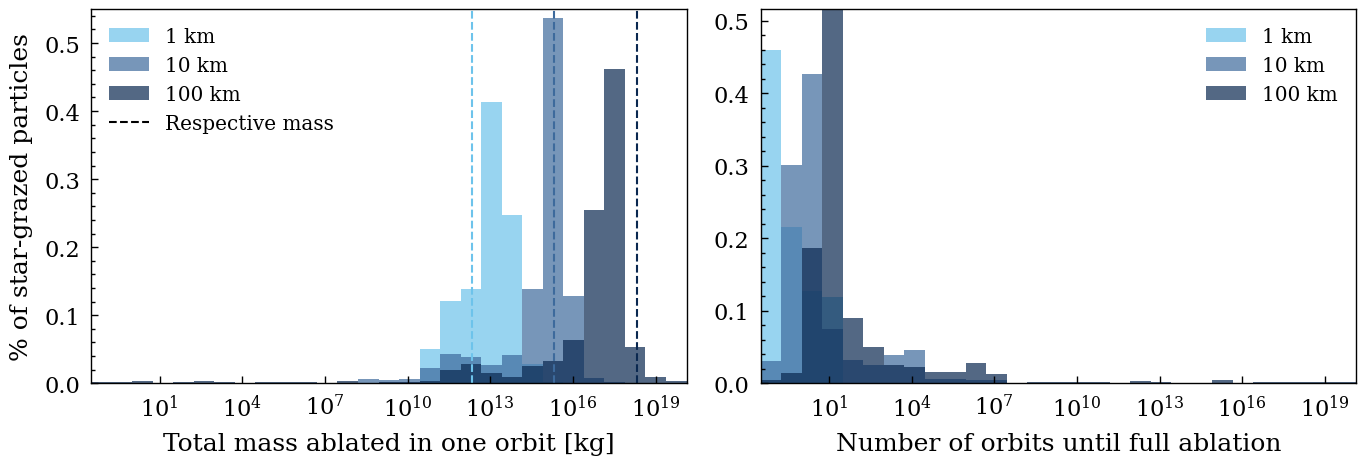

In [89]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

#browns = [ "#FD7301", "#140D01", "#f1b958" ]
browns = [ "#3D6A9C", "#0A2850", "#6dc3eb" ]

dm_1km  = np.array([results_1km[i][1] for i in range(len(results_1km))])
dm_10km  = np.array([results_10km[i][1] for i in range(len(results_10km))])
dm_100km  = np.array([results_100km[i][1] for i in range(len(results_100km))])

n_orbits_to_ablate_1km = mass_1km.value/dm_1km
n_orbits_to_ablate_10km = mass_10km.value/dm_10km
n_orbits_to_ablate_100km = mass_100km.value/dm_100km

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bins = np.logspace(
    np.log10(min( dm_10km.min(), dm_100km.min(), dm_1km.min())),
    np.log10(max( dm_10km.max(), dm_100km.max(), dm_1km.max())),
    30
)

ax[0].hist(dm_1km,  bins=bins, alpha=0.7, label='1 km', weights=np.ones_like(dm_1km) / len(dm_1km), color=browns[2])
ax[0].hist(dm_10km,  bins=bins, alpha=0.7, label='10 km', weights=np.ones_like(dm_10km) / len(dm_10km), color=browns[0])
ax[0].hist(dm_100km, bins=bins, alpha=0.7, label='100 km', weights= np.ones_like(dm_100km) / len(dm_100km),  color=browns[1])

ax[0].vlines(mass_1km.value, ymin=0, ymax=0.55, color=browns[2], linestyle='--', )
ax[0].vlines(mass_10km.value, ymin=0, ymax=0.55, color=browns[0], linestyle='--', )
ax[0].vlines(mass_100km.value, ymin=0, ymax=0.55, color=browns[1], linestyle='--',)
custom_line = Line2D([0], [0], color='black', linestyle='--', label='Respective mass')

ax[1].hist(n_orbits_to_ablate_1km, bins=bins, alpha=0.7, label='1 km', weights=np.ones_like(dm_1km) / len(dm_1km), color=browns[2], rasterized=True)
ax[1].hist(n_orbits_to_ablate_10km, bins=bins, alpha=0.7, label='10 km', weights=np.ones_like(dm_10km) / len(dm_10km), color=browns[0], rasterized=True)
ax[1].hist(n_orbits_to_ablate_100km, bins=bins, alpha=0.7, label='100 km', weights=np.ones_like(dm_100km) / len(dm_100km), color=browns[1], rasterized=True)



handles, labels = ax[0].get_legend_handles_labels()
handles.append(custom_line)
labels.append('Respective mass')
ax[0].legend(handles, labels)

for i in range(2):
    ax[i].set_xscale('log')
    ax[i].legend(handles, labels)

ax[1].legend()

ax[0].set_xlabel(r'Total mass ablated in one orbit [kg]')
ax[1].set_xlabel(r'Number of orbits until full ablation')
ax[0].set_ylabel(r'% of star-grazed particles')
plt.tight_layout()
plt.savefig('plots/histograms_total_ablation.pdf', bbox_inches='tight')
plt.show()

NameError: name 'all_grazers_2pl_100km' is not defined

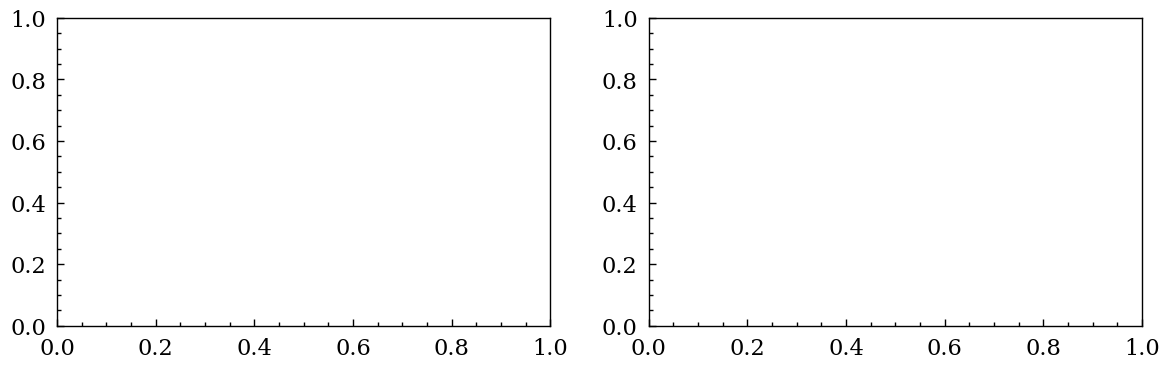

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

inclinations100 = np.array([all_grazers_2pl_100km[f][6] for f in range(len(all_grazers_2pl_100km))])
inclinations10 = np.array([all_grazers_2pl_10km[f][6] for f in range(len(all_grazers_2pl_10km))])
inclinations1 = np.array([all_grazers_2pl_1km[f][6] for f in range(len(all_grazers_2pl_1km))])

corrected100 = np.where(inclinations100 > np.pi/2, np.pi - inclinations100, inclinations100)
corrected10 = np.where(inclinations10 > np.pi/2, np.pi - inclinations10, inclinations10)
corrected1 = np.where(inclinations1 > np.pi/2, np.pi - inclinations1, inclinations1)

brownnew = "#4D331B"

for number,grazer in enumerate(all_grazers_2pl_10km[:]):
    if number == 0:
        ax[0].plot(np.degrees(corrected10[number]), results_10km[number][1], 'o', markersize=5, c=browns[0], alpha=0.7, label='10 km')
        ax[1].plot(grazer[4], results_10km[number][1], 'o', markersize=5, c=browns[0], alpha=0.7, label='10 km')
    else:
        ax[0].plot(np.degrees(corrected10[number]), results_10km[number][1], 'o', markersize=5, c=browns[0], alpha=0.7, )
        ax[1].plot(grazer[4], results_10km[number][1], 'o', markersize=5, c=browns[0], alpha=0.7)

for number, grazer in enumerate(all_grazers_2pl_100km[:]):
    if number == 0:
        ax[0].plot(np.degrees(corrected100[number]), results_100km[number][1], 'o', markersize=5, c=brownnew, alpha=0.7, label= '100 km')
        ax[1].plot(grazer[4], results_100km[number][1], 'o', markersize=5, c=brownnew, alpha=0.7, label='100 km')

    else:
        ax[0].plot(np.degrees(corrected100[number]), results_100km[number][1], 'o', markersize=5, alpha=0.7, c=brownnew)
        ax[1].plot(grazer[4], results_100km[number][1], 'o', markersize=5, alpha=0.7, c=brownnew)

for i in range(2):
    ax[i].set_yscale('log')
    ax[i].legend(loc='lower left')


ax[0].set_xlabel('inclination (degrees)')
ax[1].set_xlabel('eccentricity')
ax[0].set_ylabel('total ablation per orbit  [kg]')
plt.show()



In [43]:
print(results_100km[0][0])

[1.39253248e+18 7.72469292e+19 5.37442324e+16 5.46887923e+13
 3.79592028e+13 2.48209508e+13 1.50066501e+13 8.39001172e+12
 4.37443733e+12 2.17105698e+12 1.05341502e+12 5.11365474e+11
 2.52066730e+11 1.27129393e+11 6.57978290e+10 3.49637373e+10
 1.90607808e+10 1.06468712e+10 6.08442571e+09 3.55206286e+09
 2.11532120e+09 1.28326641e+09 7.92057233e+08 4.96814773e+08
 3.16353164e+08 2.04301137e+08 1.33692754e+08 8.85797068e+07
 5.93787507e+07 4.02445795e+07 2.75612088e+07 1.90617686e+07
 1.33071616e+07 9.37285234e+06 6.65814303e+06 4.76854297e+06
 3.44233442e+06 2.50419834e+06 1.83560616e+06 1.35571805e+06
 1.00893630e+06 7.56717795e+05 5.72139248e+05 4.36258047e+05
 3.35655228e+05 2.60763191e+05 2.04718786e+05 1.62570883e+05
 1.30728994e+05 1.06577018e+05 8.82009408e+04 7.41957487e+04
 6.35277833e+04 5.54362091e+04 4.93622724e+04 4.48984800e+04
 4.17521988e+04 3.97198241e+04 3.86688251e+04 3.85257983e+04
 3.92692524e+04 4.09262845e+04 4.35726345e+04 4.73358499e+04
 5.24014982e+04 5.902251

In [45]:
import numpy as np

angles = np.degrees(inclinations100)

targets = [0, 10, 45, 90, 180]

for target in targets:
    idx = np.argmin(np.abs(angles - target))
    print(f"closest to {target:>3}: value={angles[idx]:.6f}, index={idx}")

closest to   0: value=0.443764, index=1
closest to  10: value=9.950746, index=0
closest to  45: value=45.019667, index=489
closest to  90: value=90.445184, index=527
closest to 180: value=178.980453, index=556


In [207]:
median_inc= (np.median([all_grazers_2pl_100km[p][6] for p in range(len(all_grazers_2pl_100km))]))
print(np.degrees(median_inc))

29.824953085042875


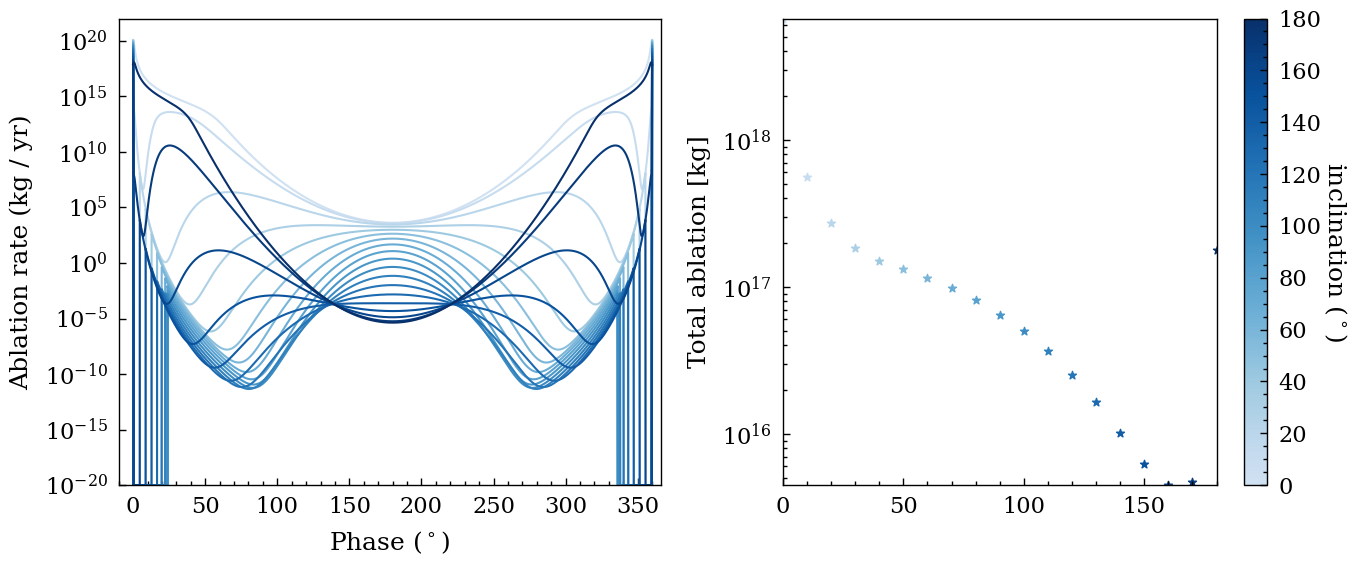

In [ ]:
import matplotlib as mpl

n_points = len(results_fake_particles[0][0])
theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)

#blues = ["#01052B", "#272C5F", "#4B5CAA", "#2C788B", "#66C9E2" ]
colors = plt.cm.Copper(np.linspace(0, 1.0, len(results_fake_particles)))

incs = np.degrees([fp[6] for fp in fake_particles])
norm = mpl.colors.Normalize(vmin=incs.min(), vmax=incs.max())
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'cropped_blues',
    plt.cm.Copper(np.linspace(0.2, 1.0, 256))
)
fig, ax = plt.subplots(1, 2, figsize=(14,6))
for n in range(len(results_fake_particles)):
    inc = incs[n]
    rate_plot = np.where(results_fake_particles[n][0] > 0, results_fake_particles[n][0], 1e-20)

    ax[0].plot(np.degrees(theta), rate_plot, color=cmap(norm(inc)),)
    ax[1].scatter(inc, results_fake_particles[n][1], marker='*', color=cmap(norm(inc)))

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax[1])
cbar.set_label(r'inclination ($^\circ$)', rotation=270, labelpad=20)

for i in range(2):
    ax[i].set_yscale('log')
ax[0].set_ylabel('Ablation rate (kg / yr)')
ax[0].set_ylim(1e-20, 1e22)
ax[0].set_xlim(-10, 366)
ax[1].set_ylabel('Total ablation [kg]')
#ax[1].set_ylim(1e44, 1e47)
ax[0].set_xlabel(r'Phase ($^\circ$)')
plt.tight_layout()
plt.savefig('plots/ablation_vs_inc_model.pdf', bbox_inches='tight')
plt.show()

#two panels, one zoomed in of the particles you'll show in the next plot. use model particles (fixed ecc and semimajor)

In [219]:
print(np.argmax(incs))

all_grazers_2pl_100km[18]
print(np.degrees(0.3894))

18
22.310976542394258


(0.0, 0.4)

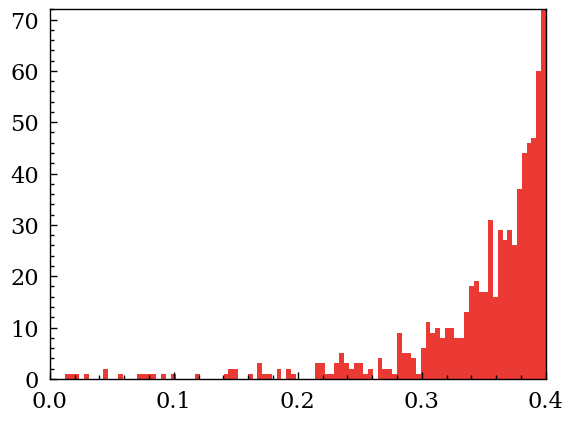

In [60]:
plt.hist(peris, bins=100)
plt.xlim(0, 0.4)

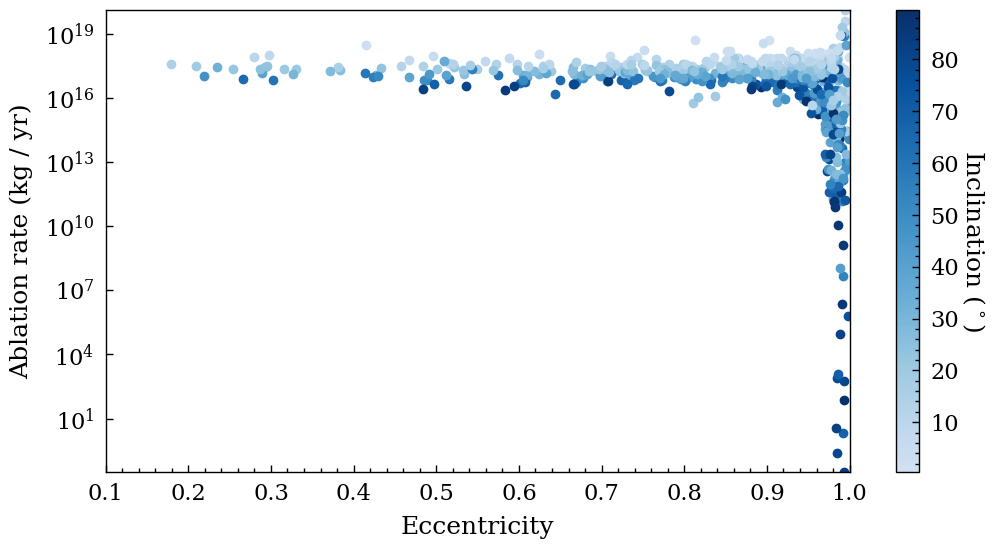

In [73]:
n_points = len(results_100km[0][0])
theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)

eccs = np.array([ all_grazers_2pl_100km[f][4] for f in range(len(all_grazers_2pl_100km))])
semis = np.array([ all_grazers_2pl_100km[f][5] for f in range(len(all_grazers_2pl_100km))])
incs_data = np.array([np.degrees(all_grazers_2pl_100km[f][6]) for f in range(len(all_grazers_2pl_100km))])

incs_data = np.where(incs_data > 90, 180 - incs_data, incs_data)

peris = semis * (1- eccs)
# choose what "close" means
threshold = 0.9  # degrees

mask = peris > 0.01

ecc_f   = eccs[mask]
inc_f   = incs_data[mask]

keys = list(results_100km.keys())

res_all = np.array([results_100km[k][1] for k in keys])
res_f = res_all[mask]

colors = plt.cm.Blues(np.linspace(0.3, 1.0, len(eccs)))

norm = mpl.colors.Normalize(vmin=incs_data.min(), vmax=incs_data.max())
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'cropped_blues',
    plt.cm.Blues(np.linspace(0.2, 1.0, 256))
)

fig, ax = plt.subplots(figsize=(12, 6))
#blues = ["#01052B", "#272C5F", "#4B5CAA", "#2C788B", "#66C9E2" ]
#blues = ['#01052B', 'navy', 'cornflowerblue', 'lightskyblue', 'aqua'] 

for i in range(len(ecc_f)):
    inc = incs_data[i]
    ax.scatter(ecc_f[i], res_f[i], color=cmap(norm(incs_data))[i])


sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r'Inclination ($^\circ$)', rotation=270, labelpad=20)
ax.set_yscale('log')
ax.set_xlim(0.1, 1)
ax.set_ylabel('Ablation rate (kg / yr)')
ax.set_xlabel('Eccentricity')
plt.savefig('plots/ablation_vs_eccentricity.pdf', bbox_inches='tight')
plt.savefig('plots/ablation_vs_eccentricity.png')
plt.show()

#1 panel - ablation vs eccentricity with inclination as a heat map

51


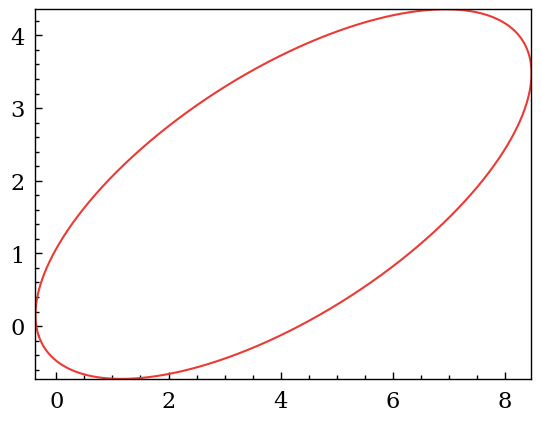

In [107]:
print(indices[2])

plt.plot((cartesian_params_100km[51]['x']*const.R_sun).to(u.AU), (cartesian_params_100km[51]['y']*const.R_sun).to(u.AU))

In [77]:
angles = np.degrees(inclinations100)

# choose what "close" means
threshold = 5  # degrees

mask = np.abs(angles) < threshold

close_to_zero = angles[mask]
indices = np.where(mask)[0]

print("indices:", indices)
print("values :", close_to_zero)

indices: [  1  39  51 127 129 263 289 293 365 371 405 409 473 495 542 554 595 665
 676 693]
values : [0.44376358 3.27129176 2.9093784  4.89116956 4.62615139 4.50314941
 3.55728024 4.9831238  3.52597318 4.53307828 2.01047467 4.70558359
 3.14803069 1.04591557 4.18251497 3.62832219 3.40989799 3.15300481
 2.65786435 2.9320407 ]


In [16]:
val = [results_100km[i][1] for i in range(len(results_100km))]

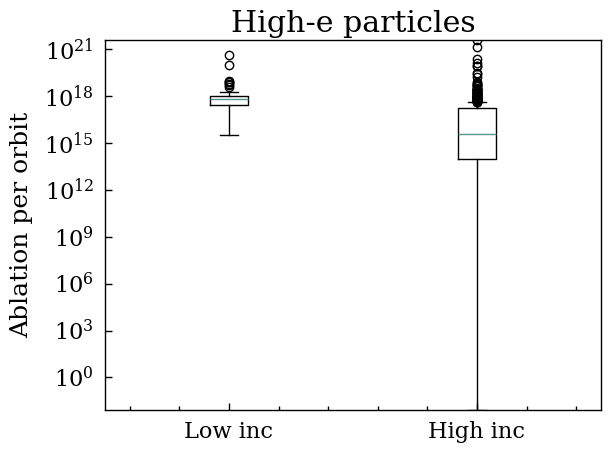

In [20]:
ecc_100 = np.array([g[4] for g in all_grazers_2pl_100km])
inc_100 = np.array([g[6] for g in all_grazers_2pl_100km])

abl_array = np.array([results_100km[i][1] for i in range(len(results_100km))])

inc_corr = np.where(inc_100 > np.pi/2, np.pi - inc_100, inc_100)

e_thresh = 0.8
inc_thresh = np.radians(10)  # low inclination = < 10 degrees

high_e = ecc_100 > e_thresh
low_inc = inc_corr < inc_thresh
high_inc = inc_corr >= inc_thresh

abl_low_inc = abl_array[high_e & low_inc]
abl_high_inc = abl_array[high_e & high_inc]

plt.boxplot([abl_low_inc, abl_high_inc], tick_labels=['Low inc', 'High inc'])
plt.yscale('log')
plt.ylabel('Ablation per orbit')
plt.title('High-e particles')
plt.show()


In [ ]:

    # print(f"Particle {p}:")
    # print(f"  r_pl = 100 km: total mass loss = {results[p][int(100)]:.2e} kg")
for i in range(10):
    plt.plot(all_grazers_2pl_10km[i]['t']/365.25, results[i]['rates_10km'])
    plt.xlabel('Time (yr)')
    plt.ylabel('Ablation Rate (kg/yr)')
    plt.title(f'Ablation Rates. Inc = {np.degrees(all_grazers_2pl_10km[i]['inc']):.2f}')
    plt.yscale('log')
    plt.show()


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

## plot inclinations over time - choose a handful of particles

In [74]:
from netCDF4 import Dataset

def get_incs_over_time(filenames):
    
    incs = []

    for f in tqdm(filenames, desc="Checking files"):
        try:
            with Dataset(f, "r") as ncfile:

                # Check if there's at least one non-empty variable

                test_particle_incs = ncfile['test_particles'][:, 6]
                test_particle_incs = test_particle_incs.filled(np.nan)
                incs.append(test_particle_incs)
        except Exception:
            continue

    return incs

# from concurrent.futures import ProcessPoolExecutor, as_completed
# from tqdm import tqdm
# import os

# # --- helper to split into chunks ---
# def chunked(lst, chunk_size):
#     for i in range(0, len(lst), chunk_size):
#         yield lst[i:i + chunk_size]

# # --- process a batch of files in one worker ---
# def process_batch(files):
#     results = []
#     for f in files:
#         try:
#             results.append(get_incs_over_time(f))
#         except Exception as e:
#             print(f"Error in {f}: {e}")
#     return results


# def combine_all_incs(filenames, chunk_size=20, max_workers=20):

#     if max_workers is None:
#         max_workers = min(16, os.cpu_count())  # cap to avoid I/O overload

#     incs_list = []

#     batches = list(chunked(filenames, chunk_size))

#     with ProcessPoolExecutor(max_workers=max_workers) as executor:
#         try:
#             futures = [executor.submit(process_batch, batch) for batch in batches]

#             for future in tqdm(as_completed(futures), total=len(futures), desc="processing"):
#                 try:
#                     batch_results = future.result(timeout=30)  # seconds per batch
#                 except Exception as e:
#                     print(f"Batch failed or timed out: {e}")
#                     continue

#                 for inc in batch_results:
#                     incs_list.append(inc)

#         except KeyboardInterrupt:
#             executor.shutdown(wait=False, cancel_futures=True)
#             raise

#     return incs_list

In [43]:
all_incs

array([], dtype=float64)

7638


Checking files: 100%|██████████| 180/180 [00:00<00:00, 196.21it/s]


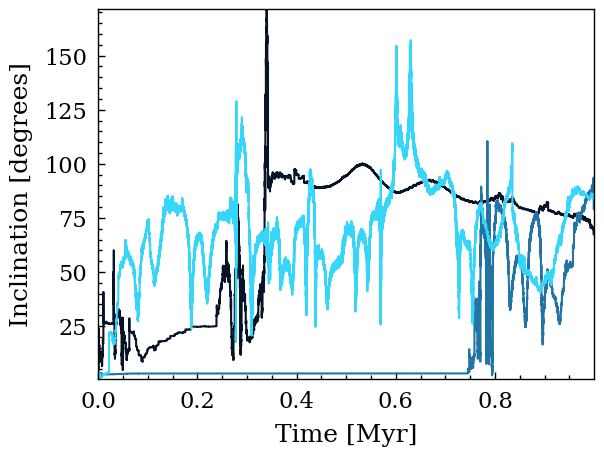

In [87]:
some_files = glob.glob('core_outputs_yr2/gas_drag_final/*100km*')
print(len(some_files))
blues = [
    "#071428",  # deep navy
    "#2174A3",  # soft sky blue
    "#35D6FA",  # light but still visible
]

count = 0
all_incs = np.degrees(get_incs_over_time(some_files[0:180]))
time_array = np.arange(0, 1, 1e-5)
for i, particle in enumerate(all_incs):
    if np.abs(particle[0] - particle[-1] ) > 50:
        plt.plot(time_array, particle, color=blues[count])
        count += 1

        if count > 2:
            break

plt.xlabel('Time [Myr]')
plt.ylabel('Inclination [degrees]')
plt.savefig('plots/inc_variation_over_time.pdf', bbox_inches='tight')
plt.show()